## Contesto e Obiettivo

Il progetto ha lo scopo di **addestrare e confrontare modelli di classificazione** in grado di classificare il livello di burnout di uno sviluppatore — suddiviso in tre categorie (`Low`, `Medium`, `High`) — a partire da variabili legate alle abitudini quotidiane di lavoro, sonno, attività fisica e stile di vita generale.

Il dataset utilizzato è **Developer Burnout Prediction Dataset** (7000 campioni), disponibile pubblicamente su Kaggle:  
[https://www.kaggle.com/datasets/asifxzaman/developer-burnout-prediction-dataset7000-samples](https://www.kaggle.com/datasets/asifxzaman/developer-burnout-prediction-dataset7000-samples)

Si tratta di un problema di classificazione multiclasse supervisionata.

### 0. Import Librerie

In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression,Perceptron
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, cohen_kappa_score,
                             classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid
from sklearn.tree import plot_tree
from sklearn.decomposition import PCA
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations

### 1. Import del dataset

Utilizziamo il sistema di upload di google.colab per caricare il nostro file .csv e da esso estrapoliamo anche il nome del file.

In [ ]:
uploaded = files.upload()
csv_file_name = next(iter(uploaded))
print(f'Caricato il file: "{csv_file_name}"')

Saving developer_burnout_dataset_7000.csv to developer_burnout_dataset_7000 (3).csv
Caricato il file: "developer_burnout_dataset_7000 (3).csv"


### 2. Caricamento del CSV in un DataFrame di Pandas



Carichiamo il dataset in un DataFrame Pandas, strumento ideale per la gestione e l'analisi di dati tabulari.  
Visualizziamo le prime e ultime righe per comprendere la struttura generale del dataset.


In [ ]:
burnout_data = pd.read_csv(csv_file_name)
display(burnout_data.head())
display(burnout_data.tail())

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
6995,25.0,14.0,6.53,7.43,5.0,1.0,7.0,5.0,7.55,1.67,20.10,Low
6996,30.0,19.0,10.15,5.60,3.0,4.0,9.0,0.0,12.11,0.96,41.71,Medium
6997,44.0,8.0,8.56,6.80,5.0,18.0,3.0,4.0,11.62,1.04,80.15,High
6998,25.0,2.0,4.39,5.40,6.0,6.0,4.0,5.0,8.24,0.82,41.44,Medium
6999,25.0,2.0,4.35,4.83,1.0,16.0,23.0,4.0,8.52,1.98,39.18,Medium


### 3. Analisi Esplorativa dei dati

#### Struttura e Variabili

Il dataset è composto da **7000 righe** e **12 colonne**. Ogni riga rappresenta il profilo di uno sviluppatore software con le seguenti variabili:

| Colonna | Descrizione |
|---|---|
| `age` | Età della persona |
| `experience_years` | Anni di esperienza lavorativa |
| `daily_work_hours` | Ore medie di lavoro al giorno |
| `sleep_hours` | Ore medie di sonno per notte |
| `caffeine_intake` | Media di bevande con caffeina al giorno |
| `bugs_per_day` | Bug medi prodotti al giorno |
| `commits_per_day` | Commit medi al giorno |
| `meetings_per_day` | Riunioni aziendali medie al giorno |
| `screen_time` | Ore medie davanti allo schermo al giorno |
| `exercise_hours` | Ore medie di attività fisica al giorno |
| `stress_level` | Punteggio di stress (numerico) |
| `burnout_level` | livello di burnout (Low / Medium / High) |

La variabile target è **burnout_level**.


#### Statistiche Descrittive e Distribuzione delle Classi

Calcoliamo le statistiche di base (media, quartili, deviazione standard) per le variabili numeriche, e la distribuzione della variabile target.

In [ ]:
print("Statistiche Descrittive")
display(burnout_data.describe())

print("\nDistribuzione Burnout Level")
display(burnout_data['burnout_level'].value_counts())



Statistiche Descrittive


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000
mean,32.129446,9.581050,9.000277,6.485638,3.540671,9.482653,14.458455,4.545044,11.974773,1.007611,53.652825
std,7.230254,5.760972,2.863944,1.445008,2.283445,5.751664,8.669846,2.856766,3.091204,0.576708,23.446656
min,20.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,5.210000,0.000000,0.000000
25%,26.000000,5.000000,6.560000,5.220000,2.000000,5.000000,7.000000,2.000000,9.460000,0.510000,36.587500
50%,32.000000,10.000000,8.990000,6.460000,4.000000,9.000000,14.000000,5.000000,12.020000,1.020000,53.795000
75%,38.000000,15.000000,11.422500,7.740000,6.000000,14.000000,22.000000,7.000000,14.422500,1.510000,70.800000
max,44.000000,19.000000,14.000000,9.000000,7.000000,19.000000,29.000000,9.000000,18.930000,2.000000,100.000000



Distribuzione Burnout Level


,count
burnout_level,
Medium,3485
High,1782
Low,1593


La distribuzione mostra che le classi sono sbilanciate in favore della classe medium, tuttavia questo verrà sistemato con il processo di SMOTE portandole in equilibrio.

#### Matrice di Correlazione

Calcoliamo la matrice di correlazione tra tutte le variabili. Per poter includere **burnout_level** nella matrice, la mappiamo temporaneamente su valori numerici.


In [ ]:
print("\nMatrice di Correlazione")
numeric_burnout_data = burnout_data.copy()

mappatura = {'Low': 0, 'Medium': 1, 'High': 2}
numeric_burnout_data['burnout_level'] = numeric_burnout_data['burnout_level'].map(mappatura)

correlation_matrix = numeric_burnout_data.corr()
display(correlation_matrix)


Matrice di Correlazione


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
age,1.000000,0.020352,-0.004627,-0.013097,-0.003913,0.002627,0.018031,0.005672,-0.002519,0.007917,0.006457,0.011811
experience_years,0.020352,1.000000,-0.018409,-0.004956,0.002975,-0.003547,-0.008876,0.003572,-0.019310,-0.003047,-0.019935,-0.018182
daily_work_hours,-0.004627,-0.018409,1.000000,-0.013728,0.007687,0.004406,-0.020833,0.005982,0.927362,0.013289,0.600880,0.546454
sleep_hours,-0.013097,-0.004956,-0.013728,1.000000,-0.018367,-0.009012,-0.002407,-0.003169,-0.007950,-0.011639,-0.249907,-0.216461
caffeine_intake,-0.003913,0.002975,0.007687,-0.018367,1.000000,0.006313,0.006454,-0.024692,0.007238,-0.003395,0.199618,0.180317
bugs_per_day,0.002627,-0.003547,0.004406,-0.009012,0.006313,1.000000,0.003480,0.014707,0.001691,0.010560,0.492421,0.457548
commits_per_day,0.018031,-0.008876,-0.020833,-0.002407,0.006454,0.003480,1.000000,0.016669,-0.017581,-0.003956,-0.007626,-0.012243
meetings_per_day,0.005672,0.003572,0.005982,-0.003169,-0.024692,0.014707,0.016669,1.000000,-0.000859,0.013622,0.351155,0.320210
screen_time,-0.002519,-0.019310,0.927362,-0.007950,0.007238,0.001691,-0.017581,-0.000859,1.000000,0.011155,0.548701,0.500237
exercise_hours,0.007917,-0.003047,0.013289,-0.011639,-0.003395,0.010560,-0.003956,0.013622,0.011155,1.000000,-0.104551,-0.098351


La matrice mostra la correlazione tra i vari dati.
Si nota molto bene come ci siano dati che hanno influenza quasi nulla sulla classificazione del burnout (**commits_per_day**, **age**, **experience_years**) e che quindi possono essere ignorate nell'allenamento dei modelli.

Dalla matrice risulta evidente anche la strettissima correlazione tra **screen_time** e **daily_work_hours**, in seguito la andiamo ad analizzare per decidere se è una informazione ridondante.

#### Relazione tra Ore di Lavoro e Tempo allo schermo

Analizziamo graficamente la correlazione tra **daily_work_hours** e **screen_time** per confermare la ridondanza tra le due variabili.


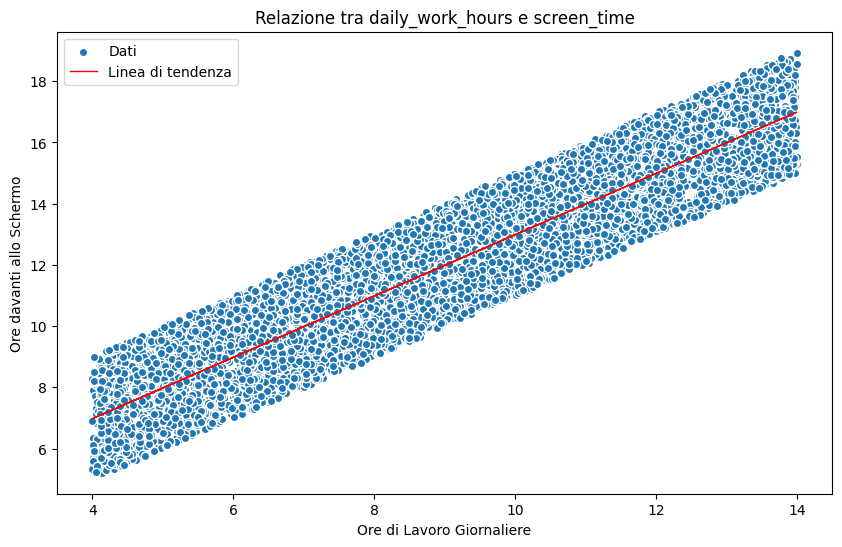

Il coefficiente di correlazione tra daily_work_hours e screen_time è: 0.93


In [ ]:
plt.figure(figsize=(10, 6))

data_cleaned = burnout_data[['daily_work_hours', 'screen_time']].dropna()

x = data_cleaned['daily_work_hours']
y = data_cleaned['screen_time']

plt.scatter(x, y, label='Dati', edgecolors="w")

m, q = np.polyfit(x, y, 1)
plt.plot(x, m*x + q, label='Linea di tendenza', color="red", linewidth=1)

plt.title('Relazione tra daily_work_hours e screen_time')
plt.xlabel('Ore di Lavoro Giornaliere')
plt.ylabel('Ore davanti allo Schermo')
plt.legend()
plt.show()
print(f"Il coefficiente di correlazione tra daily_work_hours e screen_time è: {np.corrcoef(x, y)[0, 1]:.2f}")

La linea di tendenza conferma la correlazione strettamente lineare tra le 2 variabili.
La cosa resta coerente con la realtà in quanto i lavoratori presi in esame sono informatici e quindi tendenzialmente lavorano usando un computer.
Successivamente controlliamo se ci sono casistiche in cui il tempo davanti allo schermo sia nettamente superiore alle ore di lavoro.
Per farlo abbiamo preso in esame le ore passate davanti allo schermo di chi ha meno ore di lavoro rispetto alla mediana.

In [ ]:
burnout_data[burnout_data['daily_work_hours'] < burnout_data['daily_work_hours'].median()]['screen_time'].describe()

,screen_time
count,3368.000000
mean,9.500618
std,1.864047
min,5.210000
25%,8.170000
50%,9.460000
75%,10.880000
max,13.850000


La deviazione standard è circa 1.86 ore, questo indica quanto i dati sono dispersi intorno alla media.
Una deviazione simile su una media di 9.5 ore indica una variabilità moderata. Non vengono evidenziati gruppi che stiano o tantissimo o pochissimo davanti ad uno schermo. Questo conferma la stretta relazione tra i 2 dati cosa che consente di eliminarne uno dei 2 (screen_time).

#### Rimozione delle Variabili Non Informative

Sulla base dell'analisi della correlazione, rimuoviamo le colonne che non contribuiscono alla predizione o che introdurrebbero distorsioni:
- **commits_per_day**, **age**, **experience_years** → correlazione trascurabile con il target (<0.02)  
- **screen_time** → ridondante rispetto a **daily_work_hours** (>0.80)


In [ ]:
burnout_data = burnout_data.drop(columns=['commits_per_day'])
burnout_data = burnout_data.drop(columns=['age'])
burnout_data = burnout_data.drop(columns=['experience_years'])
burnout_data = burnout_data.drop(columns=['screen_time'])
burnout_data.head()

,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,meetings_per_day,exercise_hours,stress_level,burnout_level
0,10.33,4.45,2.0,11.0,1.0,0.14,55.96,Medium
1,8.62,5.77,5.0,15.0,5.0,0.54,82.22,High
2,NaN,4.03,5.0,2.0,9.0,1.54,61.77,Medium
3,6.85,6.47,2.0,15.0,1.0,0.96,54.98,Medium
4,4.24,5.80,NaN,9.0,7.0,0.36,27.90,Low


#### Gestione dei Valori Mancanti

Verifichiamo la presenza di valori mancanti (NaN) nel dataset.


In [ ]:
print(burnout_data.isna().sum())
print(f"Numero di righe con dati mancanti: {burnout_data.isna().any(axis=1).sum()}")

daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
meetings_per_day    140
exercise_hours      140
stress_level        140
burnout_level       140
dtype: int64
Numero di righe con dati mancanti: 1042


Dalla distribuzione dei dati mancanti (NaN) notiamo che sono presenti in pari numero su ogni colonna, quindi eliminiamo tutte le righe (~14% del totale) che li contengono e rieseguiamo il controllo.

In [ ]:
burnout_data=burnout_data.dropna()

In [ ]:
burnout_data.isna().sum()


,0
daily_work_hours,0
sleep_hours,0
caffeine_intake,0
bugs_per_day,0
meetings_per_day,0
exercise_hours,0
stress_level,0
burnout_level,0


Il Dataset adesso non ha dati mancanti.

#### Heatmap di Correlazione

Visualizziamo la matrice di correlazione tramite una heatmap colorata per rendere più immediata la lettura delle relazioni tra variabili.


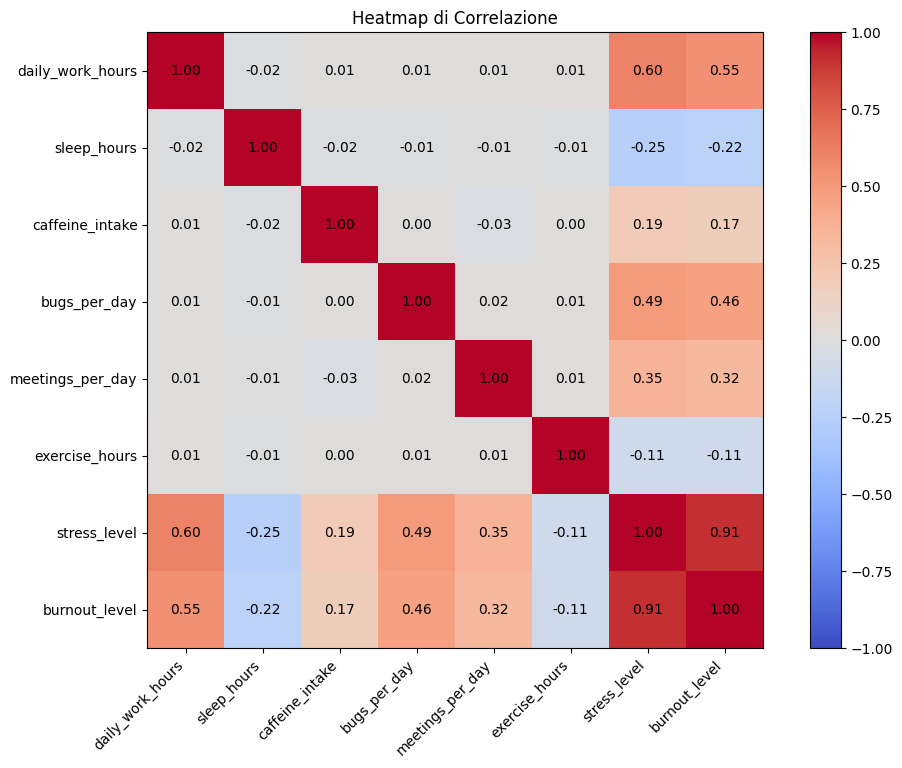

In [ ]:
numeric_burnout_data = burnout_data.copy()
numeric_burnout_data['burnout_level'] = numeric_burnout_data['burnout_level'].map(mappatura)
correlation_matrix = numeric_burnout_data.corr()

plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        valore = correlation_matrix.iloc[i, j]
        plt.text(j, i, f"{valore:.2f}", ha="center", va="center", color="black")

plt.title('Heatmap di Correlazione')
plt.show()

Risulta molto alta la dipendenza che c'è tra stress_level e burnout_level, infatti la classificazione potrebbe essere evinta solo dal livello di stress che però è un dato che non si può sapere a priori.
La colonna verrà rimossa in seguito, per il momento verrà usata per evidenziare nei grafici le relazioni tra gli altri dati e il burnout_level in quanto dato continuo e non distribuito su soli 3 valori.

#### Distribuzione della Variabile Target e delle Variabili Predittive

Visualizziamo la distribuzione della variabile target e alcune distribuzioni delle variabili predittive rispetto al livello di burnout.


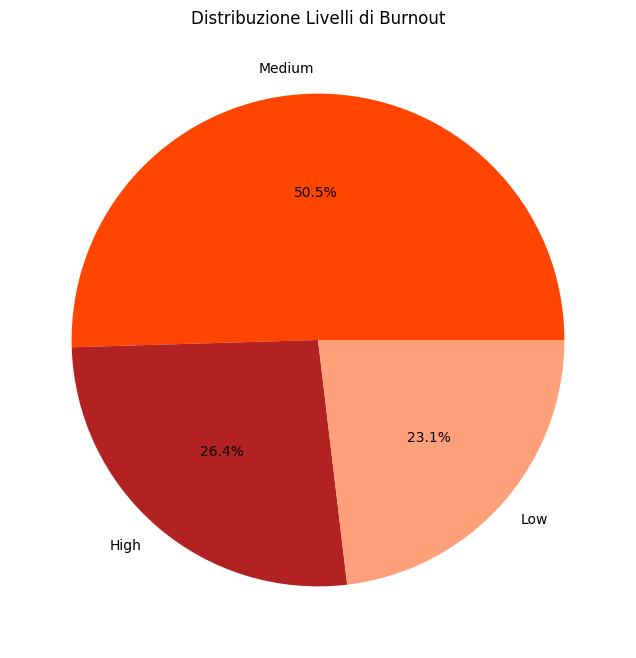

In [ ]:
colors = {'Low': 'lightsalmon', 'Medium': 'orangered', 'High': 'firebrick'}
burnout_counts = burnout_data['burnout_level'].value_counts()

pie_colors = [colors[label] for label in burnout_counts.index]

plt.figure(figsize=(8, 8))
plt.pie(burnout_counts, labels=burnout_counts.index, autopct='%1.1f%%', colors=pie_colors)
plt.title('Distribuzione Livelli di Burnout')
plt.show()

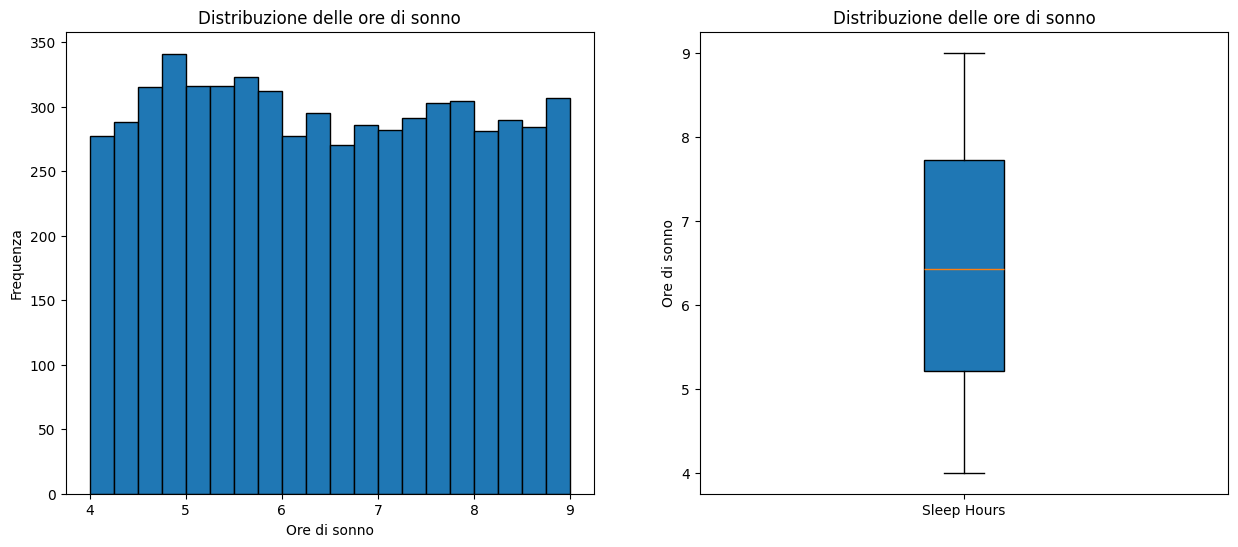

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.hist(burnout_data['sleep_hours'], bins=20, edgecolor='black')
plt.title('Distribuzione delle ore di sonno')
plt.xlabel('Ore di sonno')
plt.ylabel('Frequenza')

plt.subplot(1, 2, 2)
plt.boxplot(burnout_data['sleep_hours'], vert=True, patch_artist=True)
plt.title('Distribuzione delle ore di sonno')
plt.ylabel('Ore di sonno')
plt.xticks([1], ['Sleep Hours'])

plt.show()

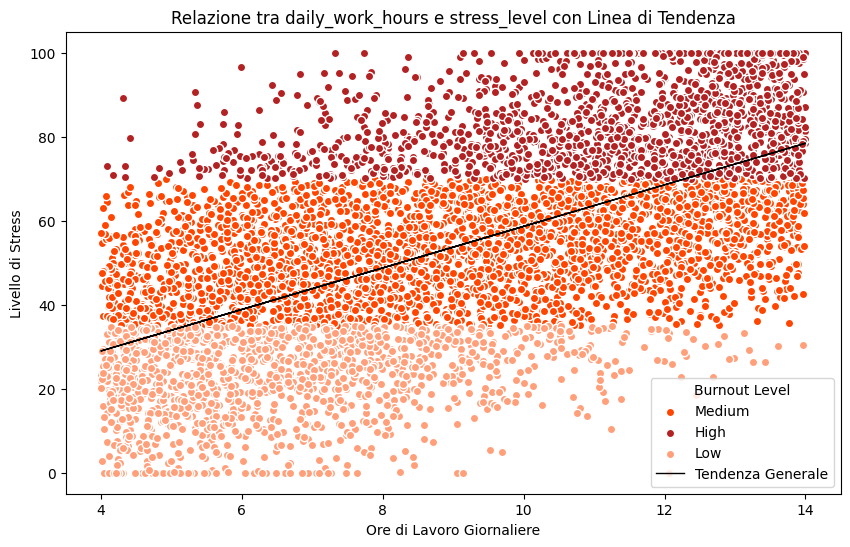

In [ ]:
plt.figure(figsize=(10, 6))

for level in burnout_data['burnout_level'].unique():
    subset = burnout_data[burnout_data['burnout_level'] == level]
    plt.scatter(subset['daily_work_hours'], subset['stress_level'],
                label=level,color=colors[level], edgecolors="w")

x = burnout_data['daily_work_hours']
y = burnout_data['stress_level']
m, q = np.polyfit(x, y, 1)
plt.plot(x, m*x + q, color='black', linewidth=1, label='Tendenza Generale')

plt.title('Relazione tra daily_work_hours e stress_level con Linea di Tendenza')
plt.xlabel('Ore di Lavoro Giornaliere')
plt.ylabel('Livello di Stress')
plt.legend(title='Burnout Level')
plt.show()

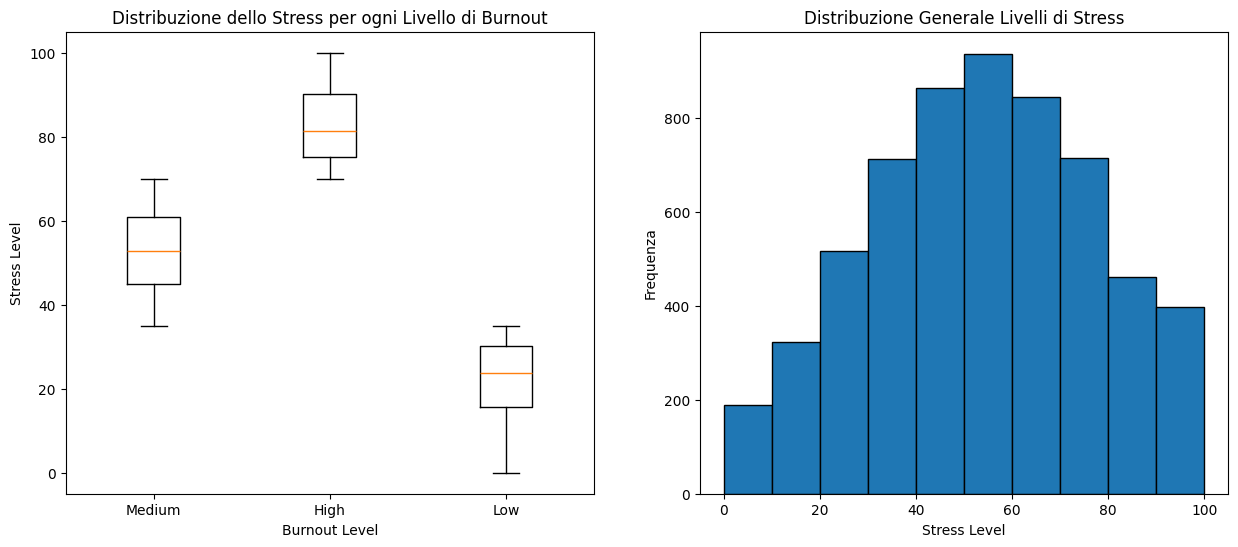

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
levels = burnout_data['burnout_level'].unique()
data_to_plot = [burnout_data[burnout_data['burnout_level'] == level]['stress_level'] for level in levels]
plt.boxplot(data_to_plot, tick_labels=levels)
plt.title('Distribuzione dello Stress per ogni Livello di Burnout')
plt.xlabel('Burnout Level')
plt.ylabel('Stress Level')

plt.subplot(1, 2, 2)
plt.hist(burnout_data['stress_level'], bins=10, edgecolor='black')
plt.title('Distribuzione Generale Livelli di Stress')
plt.xlabel('Stress Level')
plt.ylabel('Frequenza')

plt.show()

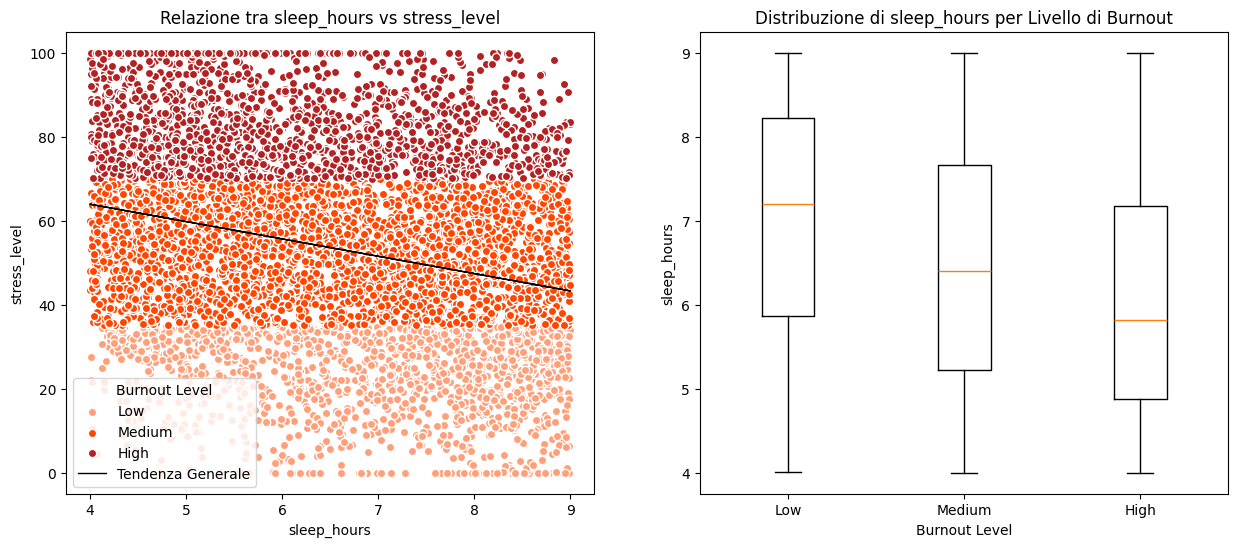

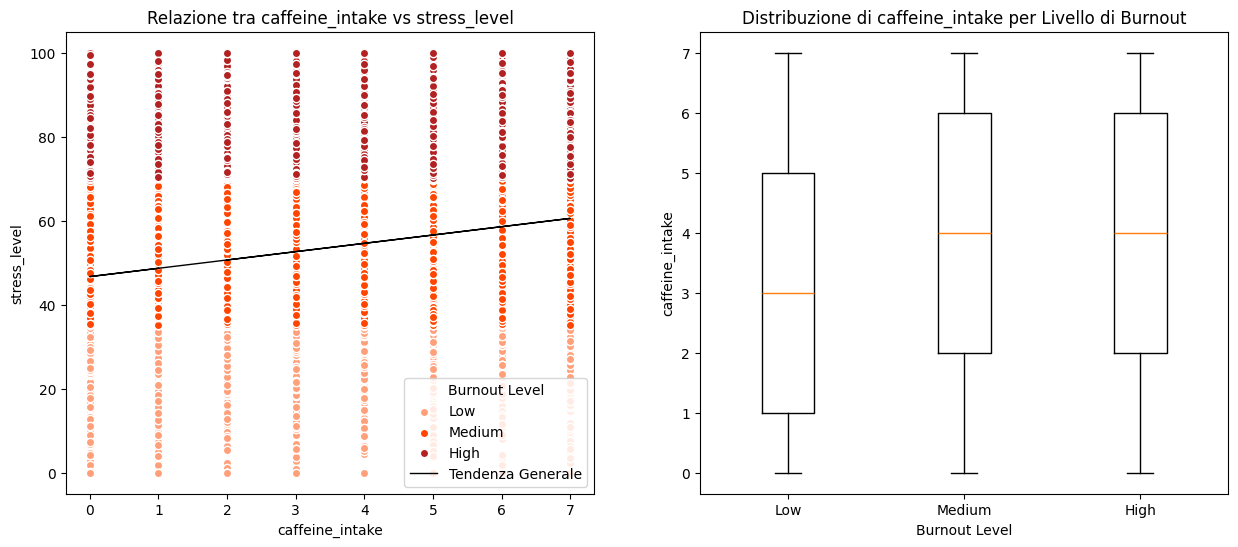

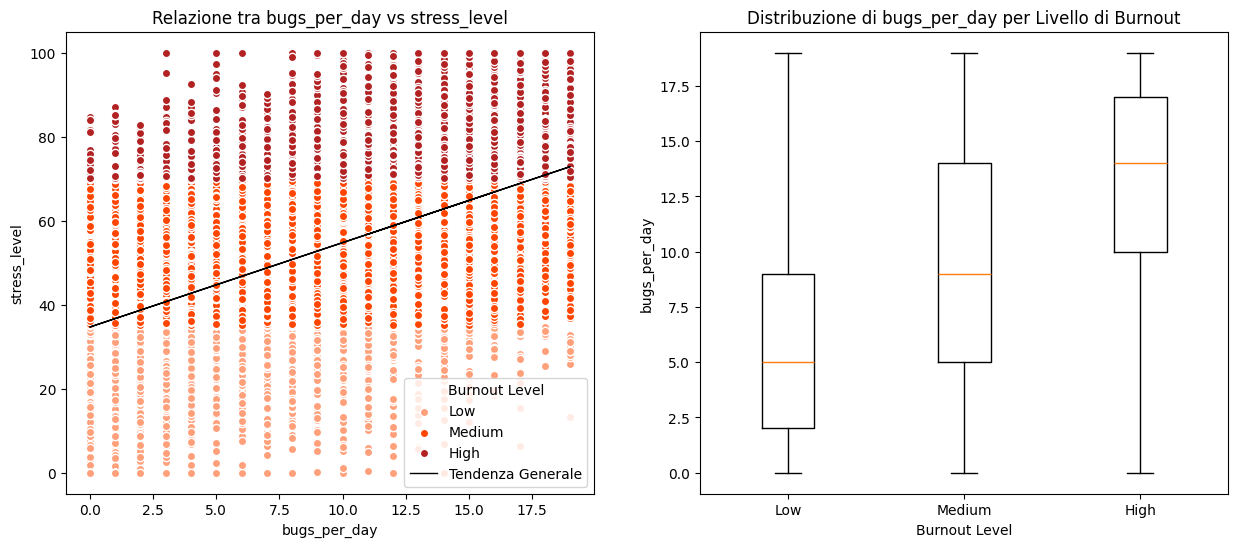

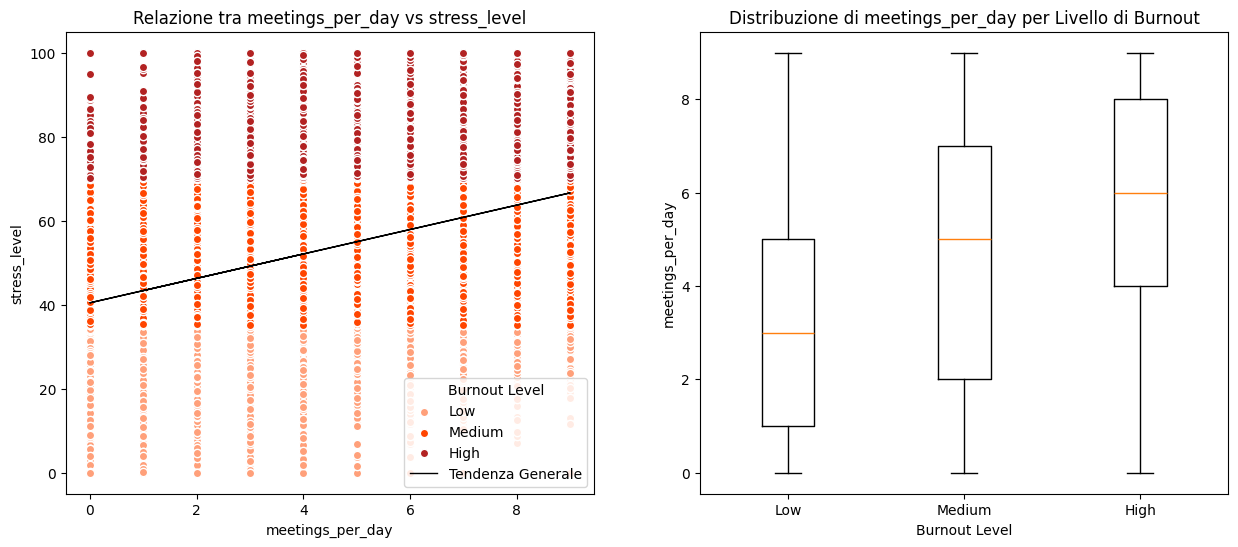

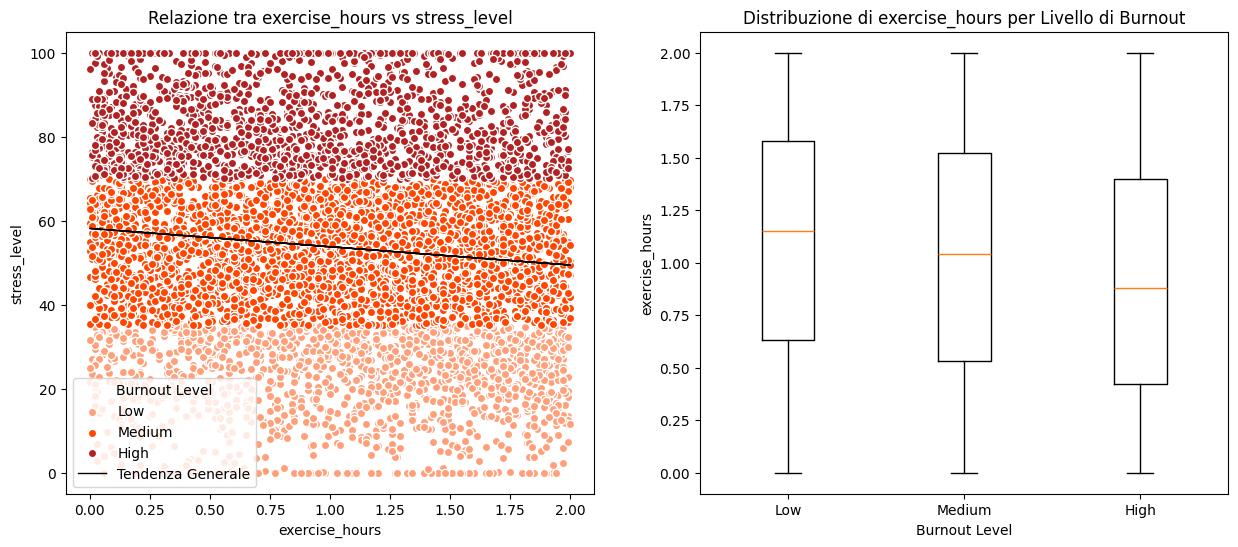

In [ ]:

columns = burnout_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'stress_level' in columns:
    columns.remove('stress_level')
    columns.remove('daily_work_hours')

for column in columns:
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    for level in ['Low', 'Medium', 'High']:
        if level in burnout_data['burnout_level'].unique():
            subset = burnout_data[burnout_data['burnout_level'] == level]
            plt.scatter(subset[column], subset['stress_level'],
                        label=level, color=colors[level], edgecolors="w")

    x_val = burnout_data[column]
    y_val = burnout_data['stress_level']
    m, q = np.polyfit(x_val, y_val, 1)
    plt.plot(x_val, m*x_val + q, color='black', linewidth=1, label='Tendenza Generale')

    plt.title(f'Relazione tra {column} vs stress_level')
    plt.xlabel(column)
    plt.ylabel('stress_level')
    plt.legend(title='Burnout Level')

    plt.subplot(1, 2, 2)
    existing_levels = [l for l in ['Low', 'Medium', 'High'] if l in burnout_data['burnout_level'].unique()]
    data_to_plot = [burnout_data[burnout_data['burnout_level'] == l][column] for l in existing_levels]

    bp = plt.boxplot(data_to_plot, tick_labels=existing_levels)

    plt.title(f'Distribuzione di {column} per Livello di Burnout')
    plt.xlabel('Burnout Level')
    plt.ylabel(column)

    plt.show()

Come evidenziato precedentemente, lo **stress_level** separa molto bene le 3 classi di burnout.
Tuttavia, questa variabile non sarebbe disponibile come input in un contesto reale (è un punteggio che si ottiene solamente in base alla diagnosi), e viene quindi rimossa per evitare **data leakage**.

In [ ]:
burnout_data = burnout_data.drop(columns=['stress_level'])
print(f"Feature finali utili all'addestramento: {list(burnout_data.columns)}")

Feature finali utili all'addestramento: ['daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'meetings_per_day', 'exercise_hours', 'burnout_level']


###  4. Preprocessing e Preparazione dei Dati

In questa fase vogliamo preparare i dati per l'addestramento dei vari modelli.
Come primo passaggio separiamo quelli che sono i dati rilevanti per la predizione da quelle che sono le label.

In [ ]:
Dati_Rilevanti = burnout_data.drop(columns=['burnout_level'])
Dati_Label = burnout_data['burnout_level']


Ci assicuriamo che ogni dato delle label sia numerico convertendole tramite label encoding e controlliamo se nei dati per la classificazione ci sia necessità di fare one-hot encoding.

In [ ]:
colonne_categoriche = Dati_Rilevanti.select_dtypes(include='object').columns.tolist()

if len(colonne_categoriche) == 0:
    print("Non essendoci variabili categoriche il one-hot encoding non e' necessario.")

ordine_burnout = {'Low': 0, 'Medium': 1, 'High': 2}
Dati_Label_Mappati = Dati_Label.map(ordine_burnout)

Non essendoci variabili categoriche il one-hot encoding non necessario.


Eseguiamo una suddivisione dei dati tra dati per il training (2/3) e dati per i test (1/3).
Per farlo sfruttiamo anche stratify in modo da mantenere le proporzioni di ogni classe all'interno dei 2 dataset.

In [ ]:
Dati_Rilevanti_Train, Dati_Rilevanti_Test, Dati_Label_Train, Dati_Label_Test = train_test_split(
    Dati_Rilevanti, Dati_Label_Mappati,
    test_size=1/3,
    random_state=42,
    stratify=Dati_Label_Mappati
)

print(f"Training set: {Dati_Rilevanti_Train.shape[0]} righe ({Dati_Rilevanti_Train.shape[0]/len(Dati_Rilevanti)*100:.0f}%)")
print(f"Test set: {Dati_Rilevanti_Test.shape[0]} righe ({Dati_Rilevanti_Test.shape[0]/len(Dati_Rilevanti)*100:.0f}%)")


Training set: 3972 righe (67%)
Test set: 1986 righe (33%)


Verifichiamo il bilanciamento tra le classi nel dataset per il train del modello.

In [ ]:
conteggi = Dati_Label_Train.value_counts().sort_index()
nomi_classi = {0: 'Low', 1: 'Medium', 2: 'High'}
print("Distribuzione classi nel training set:")
for classe, conteggio in conteggi.items():
    print(f"  {nomi_classi[classe]}: {conteggio} ({conteggio/len(Dati_Label_Train)*100:.1f}%)")

rapporto = conteggi.max() / conteggi.min()
print(f"\nRapporto max/min tra classi: {rapporto:.2f}")

Distribuzione classi nel training set:
  Low: 918 (23.1%)
  Medium: 2005 (50.5%)
  High: 1049 (26.4%)

Rapporto max/min tra classi: 2.18


Notiamo che il rapporto è molto alto infatti la classe più popolosa è più del doppio di quella meno.

Per equilibrare applichiamo l'oversampling sintetico (SMOTE) solo al dataset di train in modo da non allenare troppo i nostri modelli su una classe specifica.

In [ ]:
smote = SMOTE(random_state=42)
Dati_Rilevanti_Train_Bilanciati, Dati_Label_Train_Bilanciati = smote.fit_resample(Dati_Rilevanti_Train, Dati_Label_Train)
print("Distribuzione dopo SMOTE:")
for classe, conteggio in sorted(pd.Series(Dati_Label_Train_Bilanciati).value_counts().items()):
    print(f"{nomi_classi[classe]}: {conteggio}")

Distribuzione dopo SMOTE:
Low: 2005
Medium: 2005
High: 2005


Come ultimo passaggio della preparazione dei dati andiamo a standardizzare le feature numeriche in modo che tutte abbiano media 0 e deviazione standard 1 così che durante il training una variabile con valori più alti non acquisisca più importanza.

In [ ]:
scaler = StandardScaler()
Dati_Rilevanti_Train_Scalati = scaler.fit_transform(Dati_Rilevanti_Train_Bilanciati)
Dati_Rilevanti_Test_Scalati  = scaler.transform(Dati_Rilevanti_Test)

print(f"Media training dopo scaling: {Dati_Rilevanti_Train_Scalati.mean():.4f}")
print(f"Std training dopo scaling: {Dati_Rilevanti_Train_Scalati.std():.4f}")

Media training dopo scaling: 0.0000
Std training dopo scaling: 1.0000


### 5. Addestramento e Valutazione dei Modelli

Addestriamo e confrontiamo diversi modelli di classificazione per individuare il più efficace:

1. **Perceptron**
2. **Regressione Logistica**
3. **Decision Tree**
4. **Support Vector Machine (SVM)**
5. **XGBoost**
6. **LightGBM**

Per valutarli utilizziamo le seguenti metriche di performance:

*   **Accuracy**: Rappresenta la frazione totale di predizioni corrette sul totale di quelle fatte.
*   **Precision**: Misura l'accuratezza delle predizioni positive. Indica quanto possiamo fidarci del modello quando assegna una specifica classe di burnout.
*   **Recall**: Indica la capacità del modello di individuare tutti i casi reali appartenenti a una classe.
*   **F1-Score (Macro)**: La media armonica tra Precision e Recall.
*   **Cohen's Kappa**: Un coefficiente statistico che valuta la concordanza tra predizioni e valori reali, depurandola dalla probabilità di successo casuale.
*   **Intervallo di Confidenza (IC 95%)**: Calcolato tramite la formula di Wilson, definisce il range di incertezza statistica entro cui fluttua l'accuracy, garantendo la robustezza dei risultati ottenuti.

#### Funzioni e variabili di supporto per le metriche di performance.

Variabili di supporto e funzione per calcolare l'intervallo di confidenza al 95% con la formula di Wilson.

In [ ]:
nomi_classi_labels = ['Low', 'Medium', 'High']
z, n_test = 1.96, len(Dati_Label_Test)

def wilson_ic(acc, N=n_test, Z=z):
  den = 2 * (N + Z**2)
  var = (Z * np.sqrt(Z**2 + 4*N*acc - 4*N*acc**2)) / den
  a   = (2*N*acc + Z**2) / den
  return a - var, a + var

Funzione di supporto per il calcolo e la visualizzazione delle metriche di performance.

In [ ]:
def stampa_metriche(nome, Dati_Label_Veri, Dati_Label_Pred):
    acc  = accuracy_score(Dati_Label_Veri, Dati_Label_Pred)
    prec = precision_score(Dati_Label_Veri, Dati_Label_Pred, average='macro')
    rec  = recall_score(Dati_Label_Veri, Dati_Label_Pred, average='macro')
    f1   = f1_score(Dati_Label_Veri, Dati_Label_Pred, average='macro')
    kap  = cohen_kappa_score(Dati_Label_Veri, Dati_Label_Pred)
    ic_min, ic_max = wilson_ic(acc)
    print(f"{nome}")
    print(f"Accuracy:{acc:.2%}")
    print(f"Precision:{prec:.2%}")
    print(f"Recall:{rec:.2%}")
    print(f"F1-score:{f1:.2%}")
    print(f"Tasso di errore:{1-acc:.2%}")
    print(f"Cohen's Kappa:{kap:.2%}")
    print(f"IC 95%:[{ic_min:.2%} — {ic_max:.2%}]")
    print(classification_report(Dati_Label_Veri, Dati_Label_Pred, target_names=nomi_classi_labels))
    return {'Modello': nome, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 (macro)': f1, 'Kappa': kap, 'IC min': ic_min, 'IC max': ic_max}

Funzione di supporto per visualizzare la matrice di confusione.

In [ ]:
def plot_confusion_matrix(Dati_Label_Veri, Dati_Label_Pred, nome):
    cm = confusion_matrix(Dati_Label_Veri, Dati_Label_Pred)
    plt.figure(figsize=(7, 5))
    plt.imshow(cm, cmap='coolwarm')
    plt.colorbar()
    plt.xticks(range(3), nomi_classi_labels)
    plt.yticks(range(3), nomi_classi_labels)
    plt.xlabel('Classe Predetta')
    plt.ylabel('Classe Reale')
    plt.title(f'Matrice di Confusione — {nome}')
    for i in range(3):
        for j in range(3):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white', fontsize=14, fontweight='bold')
    plt.show()

Funzione di supporto per visualizzare i coefficenti di peso dei modelli lineari.

In [ ]:
def coeff_calc(model, name):
  coefficienti = pd.DataFrame(
      model.coef_,
      index=nomi_classi_labels,
      columns=Dati_Rilevanti.columns
  )

  print("Coefficienti del modello "+name+":")
  display(coefficienti.T.style.background_gradient(cmap='coolwarm', axis=None))

Creiamo un dizionario in cui verranno salvate le predizioni di ogni modello per poi eseguire un confronto finale.

In [ ]:
predizioni_finali = {}

Per l'allenamento e il controllo dei risultati utilizziamo delle funzioni globali.

Funzione per mostrare le decisioni dei Decision Tree

In [ ]:
def showTree(model):
  plt.figure(figsize=(7, 5))
  plot_tree(model, feature_names=Dati_Rilevanti_Train_Bilanciati.columns.to_list(), filled=True, rounded=True);
  plt.show()

Funzione per mostrare il grafico dell'SVM

In [ ]:
def showSVM(grid_search=None):
  scaler_vis = StandardScaler()
  Train_scalato = scaler_vis.fit_transform(Dati_Rilevanti_Train_Bilanciati)
  Test_scalato = scaler_vis.transform(Dati_Rilevanti_Test)
  pca = PCA(n_components=2, random_state=42)
  Dati_Rilevanti_2d_Train = pca.fit_transform(Train_scalato)
  Dati_Rilevanti_2d_Test  = pca.transform(Test_scalato)

  if grid_search != None:
    best_svm_params = {k.replace('svm__', ''): v
                   for k, v in grid_search.best_params_.items()
                   if k.startswith('svm__')}

    svm_2d = SVC(**best_svm_params,random_state=42)
  else:
    svm_2d = SVC(random_state=42)
  svm_2d.fit(Dati_Rilevanti_2d_Train, Dati_Label_Train_Bilanciati)

  x_min = min(Dati_Rilevanti_2d_Train[:, 0].min(), Dati_Rilevanti_2d_Test[:, 0].min()) - 0.5
  x_max = max(Dati_Rilevanti_2d_Train[:, 0].max(), Dati_Rilevanti_2d_Test[:, 0].max()) + 0.5
  y_min = min(Dati_Rilevanti_2d_Train[:, 1].min(), Dati_Rilevanti_2d_Test[:, 1].min()) - 0.5
  y_max = max(Dati_Rilevanti_2d_Train[:, 1].max(), Dati_Rilevanti_2d_Test[:, 1].max()) + 0.5

  xx, yy = np.meshgrid(
      np.linspace(x_min, x_max, 300),
      np.linspace(y_min, y_max, 300)
  )

  Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

  fig, ax = plt.subplots(figsize=(10, 7))
  ax.contourf(xx, yy, Z, alpha=0.25, levels=[-0.5, 0.5, 1.5, 2.5],
              colors=list(colors.values()))
  ax.contour(xx, yy, Z, levels=[0.5, 1.5], colors='black', linewidths=1.5, linestyles='--')

  for classe, colore, etichetta in zip([0, 1, 2], colors.values(), nomi_classi_labels):
      maschera = Dati_Label_Test.values == classe
      ax.scatter(Dati_Rilevanti_2d_Test[maschera, 0], Dati_Rilevanti_2d_Test[maschera, 1],
                  c=colore, label=f'Test — {etichetta}', edgecolors='white', s=40, alpha=0.8)

  sv_coords = svm_2d.support_vectors_
  sv_labels = svm_2d.predict(sv_coords)
  for classe, colore in zip([0, 1, 2], colors.values()):
      mask_sv = sv_labels == classe
      if np.any(mask_sv):
          ax.scatter(sv_coords[mask_sv, 0], sv_coords[mask_sv, 1], s=75, facecolors=colore,
                      edgecolors='black', linewidths=1.5, alpha=1.0, label=f'SV — {nomi_classi_labels[classe]}')

  var = pca.explained_variance_ratio_
  ax.set_xlabel(f'PC1 ({var[0]:.1%} varianza)')
  ax.set_ylabel(f'PC2 ({var[1]:.1%} varianza)')
  ax.set_title('SVM — Decision Boundary e Support Vectors (PCA 2D)')
  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.show()
  print(f"Varianza totale spiegata: {sum(var):.2%}")
  n_sv = svm_2d.n_support_
  print("Support Vectors per classe:")
  for nome_classe, n in zip(['Low', 'Medium', 'High'], n_sv):
      print(f"{nome_classe}: {n} support vectors")
  print(f"Totale: {sum(n_sv)} su {len(Dati_Rilevanti_Train_Bilanciati)} esempi di training")
  print(f"({sum(n_sv)/len(Dati_Rilevanti_Train_Bilanciati)*100:.1f}% dei dati di training sono support vectors)")

Funzione per mostrare i dati considerati più importanti dal modello (usata in XGBoost e LightGBM)

In [ ]:
def showFeatureImportance(model, nome):
  if hasattr(model, 'named_steps'):
      step_name = list(model.named_steps.keys())[-1]
      clf = model.named_steps[step_name]
  else:
      clf = model

  importances = clf.feature_importances_
  feature_names = Dati_Rilevanti.columns.tolist()

  plt.figure(figsize=(8, 5))
  sorted_idx = np.argsort(importances)
  plt.barh([feature_names[i] for i in sorted_idx],
            importances[sorted_idx], color='steelblue')
  plt.xlabel('Importanza')
  plt.title(f'Feature Importance — {nome}')
  plt.show()

Funzione per allenare e testare un modello

In [ ]:
def Train_and_Test(model, nome):
  model.fit(Dati_Rilevanti_Train_Bilanciati, Dati_Label_Train_Bilanciati)
  Dati_Label_Predetti = model.predict(Dati_Rilevanti_Test)
  risultati = stampa_metriche(nome, Dati_Label_Test, Dati_Label_Predetti)
  predizioni_finali[nome] = Dati_Label_Predetti
  plot_confusion_matrix(Dati_Label_Test, Dati_Label_Predetti, nome)

  if nome in ['lr', 'perceptron']:
    coeff_calc(model.named_steps[nome], nome)
  elif nome == 'Ds':
    showTree(model)
  elif nome in ['xgboost', 'lightgbm']:
    showFeatureImportance(model, nome)
  else:
    showSVM()

Funzione per allenare e testare un modello utilizzando la grid search

In [ ]:
def Train_and_Test_GridSearch(pipeline_model, grid, nome):
  grid_search = GridSearchCV(
    pipeline_model, grid, cv=5, scoring='accuracy', n_jobs=-1
  )
  grid_search.fit(Dati_Rilevanti_Train_Bilanciati, Dati_Label_Train_Bilanciati)
  print("Migliori iperparametri per " + nome + ":", grid_search.best_params_)
  best_grid_model = grid_search.best_estimator_
  Dati_Label_Predetti = best_grid_model.predict(Dati_Rilevanti_Test)
  risultati = stampa_metriche(nome, Dati_Label_Test, Dati_Label_Predetti)
  predizioni_finali[nome + ' (GS)'] = Dati_Label_Predetti
  plot_confusion_matrix(Dati_Label_Test, Dati_Label_Predetti, nome)

  if nome in ['lr', 'perceptron']:
    coeff_calc(best_grid_model.named_steps[nome], nome)
  elif nome == 'Ds':
    tree = best_grid_model.named_steps['Ds']
    showTree(tree)
  elif nome in ['xgboost', 'lightgbm']:
    showFeatureImportance(best_grid_model, nome)
  else:
    showSVM(grid_search)

### Perceptron

Il **Perceptron** è il classificatore lineare più semplice.

Gli iperparametri principali sono:
*   **penalty (Regolarizzazione)**: Definisce il tipo di penalità applicata ai pesi per prevenire l'overfitting.
    *   `l2`: Distribuisce l'errore tra tutti i pesi (approccio standard).
    *   `l1`: Tende ad azzerare i pesi delle feature meno importanti.
    *   `elasticnet`: Una combinazione bilanciata tra l1 e l2.
*   **alpha (Costante di Regolarizzazione)**: Determina l'intensità della penalità definita sopra.

Prima di tutto proviamo ad allenare un Perceptron senza modificare gli iperparametri di default.

perceptron
Accuracy:63.85%
Precision:64.59%
Recall:69.64%
F1-score:65.16%
Tasso di errore:36.15%
Cohen's Kappa:45.71%
IC 95%:[61.71% — 65.93%]
              precision    recall  f1-score   support

         Low       0.67      0.81      0.73       459
      Medium       0.72      0.47      0.57      1002
        High       0.55      0.81      0.65       525

    accuracy                           0.64      1986
   macro avg       0.65      0.70      0.65      1986
weighted avg       0.66      0.64      0.63      1986



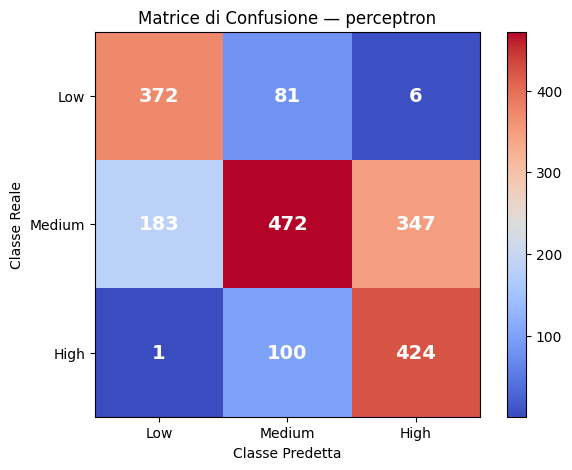

Coefficienti del modello perceptron:


,Low,Medium,High
daily_work_hours,-7.764589,-0.074901,7.068842
sleep_hours,3.456296,2.221557,0.388886
caffeine_intake,-1.483806,-1.901825,4.963473
bugs_per_day,-3.279693,2.535365,5.235302
meetings_per_day,-3.411426,1.779333,3.083919
exercise_hours,0.493012,1.188474,1.171577


In [ ]:
pipeline_perceptron = Pipeline([
    ('scaler', StandardScaler()),
    ('perceptron', Perceptron(random_state=42, max_iter=1000))
])
Train_and_Test(pipeline_perceptron,"perceptron")

Si può notare come, essendo un modello molto semplice, abbia delle metriche di performance molto basse quindi tentiamo di migliorarlo andando a ricercare degli iperparametri migliori con la GridSearch.

Migliori iperparametri per perceptron: {'perceptron__alpha': 0.0001, 'perceptron__penalty': 'l1'}
perceptron
Accuracy:67.98%
Precision:68.61%
Recall:73.77%
F1-score:68.78%
Tasso di errore:32.02%
Cohen's Kappa:52.06%
IC 95%:[65.89% — 69.99%]
              precision    recall  f1-score   support

         Low       0.66      0.78      0.72       459
      Medium       0.79      0.50      0.62      1002
        High       0.60      0.93      0.73       525

    accuracy                           0.68      1986
   macro avg       0.69      0.74      0.69      1986
weighted avg       0.71      0.68      0.67      1986



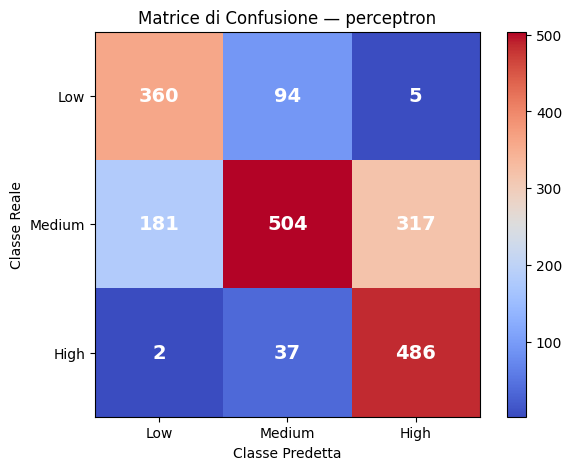

Coefficienti del modello perceptron:


,Low,Medium,High
daily_work_hours,-3.679417,0.000000,4.973197
sleep_hours,4.251144,-0.344997,-1.496797
caffeine_intake,-3.080752,0.000000,0.701438
bugs_per_day,-3.374132,0.000000,2.913878
meetings_per_day,-3.364972,0.000000,3.733750
exercise_hours,2.728163,0.000000,-0.603165


In [ ]:
grid_perceptron = {
    'perceptron__penalty': [None, 'l2', 'l1', 'elasticnet'],
    'perceptron__alpha': [0.000001,0.00001,0.0001, 0.001, 0.01, 0.1, 1]
}

Train_and_Test_GridSearch(pipeline_perceptron,grid_perceptron,'perceptron')

Dopo aver ottimizzato i parametri notiamo che il modello è migliorato nei nostri casi di test.

#### Regressione Logistica

La **Regressione Logistica** estende il modello lineare assegnando probabilità a ogni classe tramite la funzione softmax.

Gli iperparametri principali sono:

*   **penalty (Regolarizzazione)**: Definisce il tipo di penalità applicata ai pesi per prevenire l'overfitting.
    *   `l2`: Distribuisce l'errore tra tutti i pesi (approccio standard).
    *   `l1`: Tende ad azzerare i pesi delle feature meno importanti.
    *   `elasticnet`: Una combinazione bilanciata tra l1 e l2.
    *   `'none'`: Nessuna penalità.

*   **`C` (Inverso della forza di regolarizzazione)**: È l'iperparametro che controlla l'intensità della regolarizzazione.

*   **`l1_ratio`**: Usato solo con `penalty='elasticnet'`, questo parametro definisce il rapporto tra la penalità L1 e L2. Un valore di `0` è equivalente a solo L2, un valore di `1` è equivalente a solo L1.

Come per il perceptron alleniamo prima un modello senza modificare gli iperparametri di default.

lr
Accuracy:78.20%
Precision:77.31%
Recall:80.74%
F1-score:78.59%
Tasso di errore:21.80%
Cohen's Kappa:66.01%
IC 95%:[76.33% — 79.96%]
              precision    recall  f1-score   support

         Low       0.74      0.86      0.80       459
      Medium       0.83      0.71      0.77      1002
        High       0.75      0.85      0.79       525

    accuracy                           0.78      1986
   macro avg       0.77      0.81      0.79      1986
weighted avg       0.79      0.78      0.78      1986



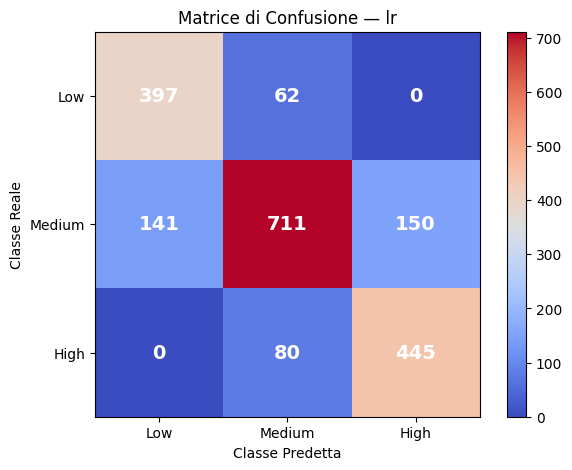

Coefficienti del modello lr:


,Low,Medium,High
daily_work_hours,-2.864272,0.069565,2.794707
sleep_hours,1.118237,-0.060719,-1.057518
caffeine_intake,-0.928611,0.016420,0.912191
bugs_per_day,-2.332354,0.009269,2.323085
meetings_per_day,-1.613129,0.028565,1.584564
exercise_hours,0.591503,0.009375,-0.600878


In [ ]:
Logistic_Regression_Model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ("lr", LogisticRegression(solver="saga",random_state=42, max_iter=1000))
])

Train_and_Test(Logistic_Regression_Model_pipeline,"lr")

Esendo un modello un pò più complesso notiamo subito un miglioramento delle performance rispetto al perceptron.

Migliori iperparametri per lr: {'lr__C': np.float64(0.1), 'lr__l1_ratio': 0.5, 'lr__penalty': 'elasticnet'}
lr
Accuracy:78.05%
Precision:77.15%
Recall:80.67%
F1-score:78.44%
Tasso di errore:21.95%
Cohen's Kappa:65.81%
IC 95%:[76.17% — 79.81%]
              precision    recall  f1-score   support

         Low       0.73      0.86      0.79       459
      Medium       0.83      0.71      0.76      1002
        High       0.75      0.85      0.80       525

    accuracy                           0.78      1986
   macro avg       0.77      0.81      0.78      1986
weighted avg       0.79      0.78      0.78      1986



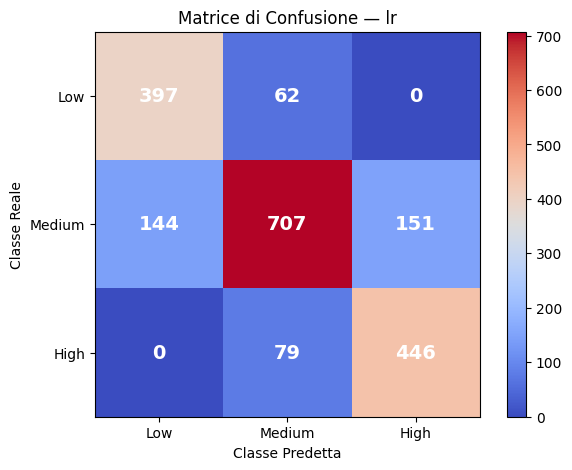

Coefficienti del modello lr:


,Low,Medium,High
daily_work_hours,-2.625141,0.000000,2.461136
sleep_hours,1.051284,0.000000,-0.893032
caffeine_intake,-0.841422,0.000000,0.802902
bugs_per_day,-2.093356,0.000000,2.090273
meetings_per_day,-1.462255,0.000000,1.400556
exercise_hours,0.514424,0.000000,-0.543345


In [ ]:
grid = [
    {
        "lr__penalty": [None]
    },
    {
        "lr__penalty": ["l2", "l1"],
        "lr__C": np.logspace(-2, 2, 5)
    },
    {
        "lr__penalty": ["elasticnet"],
        "lr__C": np.logspace(-2, 2, 5),
        "lr__l1_ratio": [0.2, 0.5]
    }
]

Train_and_Test_GridSearch(Logistic_Regression_Model_pipeline,grid,'lr')

Abbiamo eseguito la GridSearch e abbiamo notato che le performance del modello diminuiscono leggermente, sospettiamo che sia per via di overfitting nel primo modello (quello senza ricerca degli iperparametri) e che quindi al costo di una riduzione di performance il modello dovrebbe andare meglio su diversi insiemi di casi di test.

### Decision Tree

Il **Decision Tree** (albero decisionale) è un modello che suddivide ricorsivamente lo spazio delle feature tramite regole di tipo `if/else`. Ogni nodo interno rappresenta un test su una feature, ogni foglia rappresenta una classe predetta.

Gli iperparametri principali sono:
* **max_depth**: profondità dell'albero (quanti nodi figli ci sono), se limitata troppo non si ottimizza l'accuratezza se troppo alta tende all'overfitting.

**Vantaggi**: completamente interpretabile, non richiede standardizzazione, gestisce relazioni non lineari.  
**Svantaggi**: tende all'overfitting se non si limita la profondità (`max_depth`).

Ds
Accuracy:67.82%
Precision:67.22%
Recall:69.28%
F1-score:68.08%
Tasso di errore:32.18%
Cohen's Kappa:49.30%
IC 95%:[65.74% — 69.84%]
              precision    recall  f1-score   support

         Low       0.64      0.73      0.68       459
      Medium       0.70      0.64      0.67      1002
        High       0.67      0.72      0.69       525

    accuracy                           0.68      1986
   macro avg       0.67      0.69      0.68      1986
weighted avg       0.68      0.68      0.68      1986



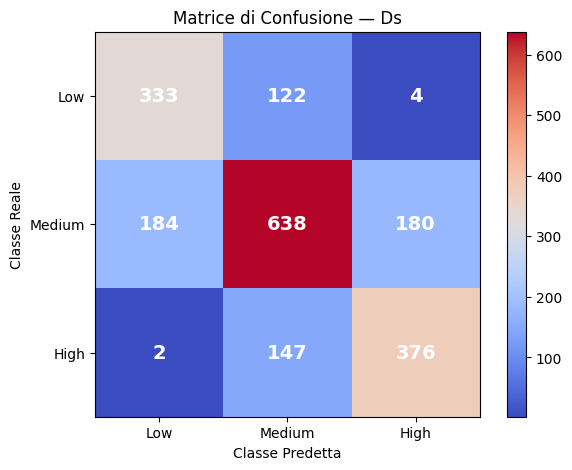

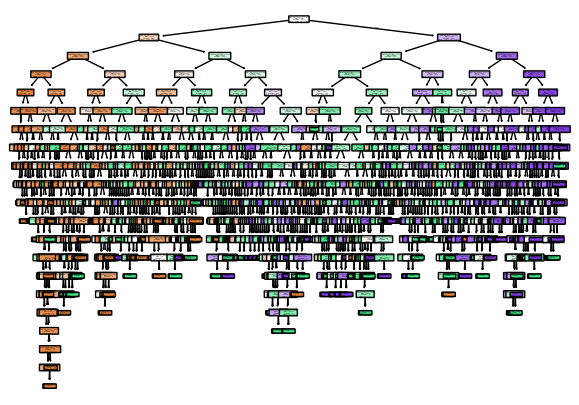

In [ ]:
DecisionTree_Model = DecisionTreeClassifier()
Train_and_Test(DecisionTree_Model,"Ds")

Vediamo come il modello di base (senza max_depth impostato) tende a creare numerosi nodi figli avendo comunque una accuratezza bassa. (In questo caso abbiamo una profondità di 20)

Migliori iperparametri per Ds: {'Ds__max_depth': 9}
Ds
Accuracy:69.03%
Precision:68.37%
Recall:71.59%
F1-score:69.54%
Tasso di errore:30.97%
Cohen's Kappa:51.78%
IC 95%:[66.96% — 71.03%]
              precision    recall  f1-score   support

         Low       0.64      0.78      0.70       459
      Medium       0.73      0.62      0.67      1002
        High       0.68      0.75      0.71       525

    accuracy                           0.69      1986
   macro avg       0.68      0.72      0.70      1986
weighted avg       0.70      0.69      0.69      1986



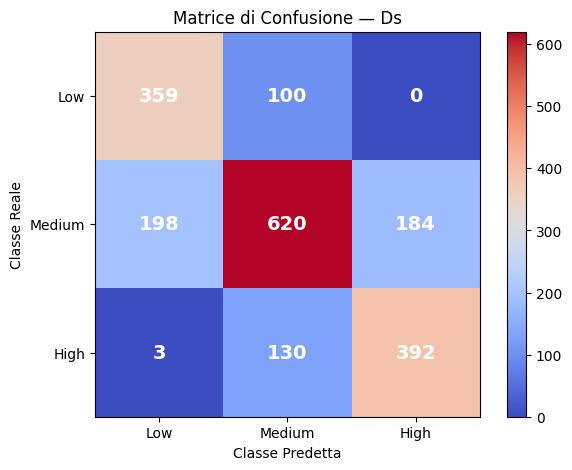

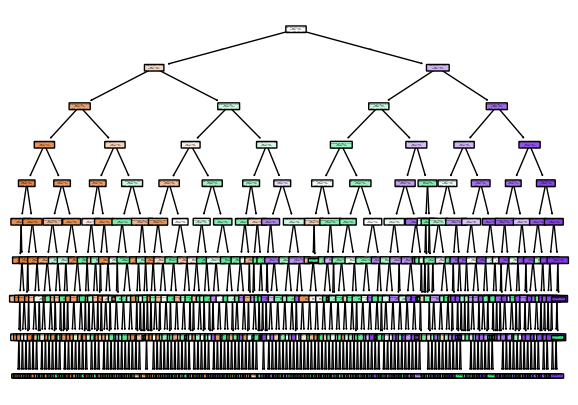

In [ ]:
Decision_Tree_Pipeline = Pipeline([
    ("Ds", DecisionTreeClassifier())
])

grid = [
    {
        "Ds__max_depth": [1,2,3,4,5,6,7,8,9,10]
    }
]

Train_and_Test_GridSearch(Decision_Tree_Pipeline,grid,'Ds')

In questo caso invece utilizzando la ricerca degli iperparametri scopriamo che il numero ottimale di max_depth corrisponde a 9.
Grazie a questo si può notare un miglioramento nelle performance del modello.

#### Support Vector Machine (SVM)


Le **Support Vector Machine (SVM)** cercano di trovare l'iperpiano di separazione ottimale che massimizza il margine tra le diverse classi.

Gli iperparametri principali sono:

*   **kernel**: La funzione matematica usata per la trasformazione. Proietta i dati originali in uno spazio a più dimensioni dove diventa possibile tracciare un confine netto tra essi.
    *   `linear`: Assume che i dati siano già separabili da una linea retta.
    *   `rbf` (Radial Basis Function): Crea confini decisionali circolari o ovali attorno ai punti.
*   **C (Regolarizzazione)**: Controlla il compromesso tra la massimizzazione del margine e la corretta classificazione dei punti di training.
    *   *C basso*: Margine più ampio (modello più semplice, rischia underfitting).
    *   *C alto*: Tenta di classificare correttamente tutti i punti (modello complesso, rischia overfitting).
*   **gamma**: Specifica quanto è "ampio" il raggio di influenza di un singolo esempio di training (usato con RBF).
    *   *gamma basso*: Influenza a lungo raggio (confini morbidi).
    *   *gamma alto*: Influenza a corto raggio (confini molto irregolari che seguono i singoli punti).


svm
Accuracy:77.54%
Precision:76.66%
Recall:80.15%
F1-score:77.95%
Tasso di errore:22.46%
Cohen's Kappa:65.02%
IC 95%:[75.66% — 79.32%]
              precision    recall  f1-score   support

         Low       0.73      0.86      0.79       459
      Medium       0.83      0.70      0.76      1002
        High       0.75      0.84      0.79       525

    accuracy                           0.78      1986
   macro avg       0.77      0.80      0.78      1986
weighted avg       0.78      0.78      0.77      1986



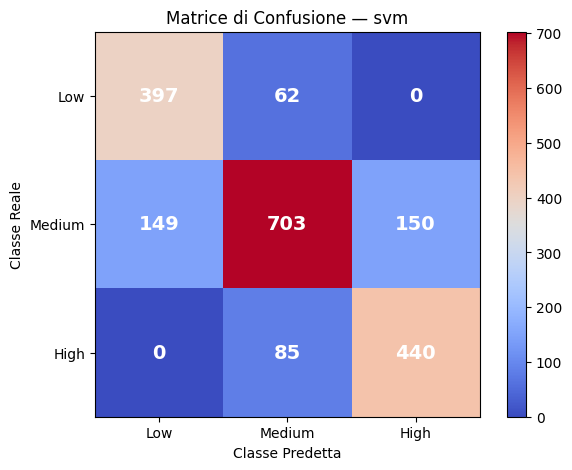

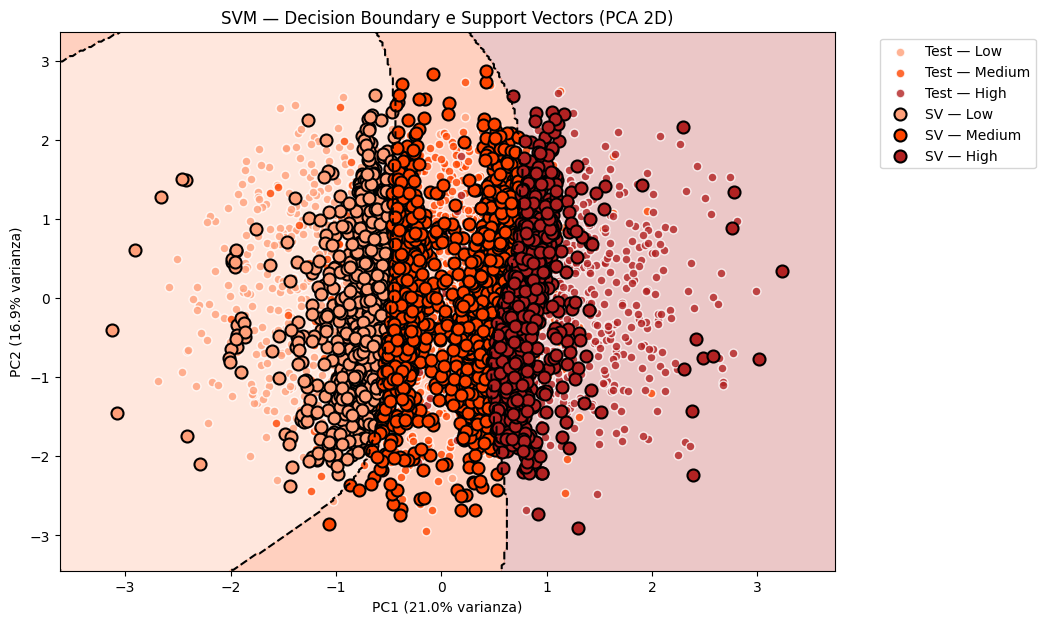

Varianza totale spiegata: 37.84%
Support Vectors per classe:
Low: 667 support vectors
Medium: 1384 support vectors
High: 739 support vectors
Totale: 2790 su 6015 esempi di training
(46.4% dei dati di training sono support vectors)


In [ ]:
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ("svm", SVC(random_state=42))
])
Train_and_Test(svm_model,"svm")

Come per gli altri abbiamo provato ad allanare un primo modello con gli iperparametri di default.
Possiamo notare come l'accuratezza migliori rispetto agli altri anche senza la ricerca degli iperparametri ottimali.

Migliori iperparametri per svm: {'svm__C': 2, 'svm__gamma': 3, 'svm__kernel': 'rbf'}
svm
Accuracy:72.51%
Precision:74.03%
Recall:69.63%
F1-score:71.36%
Tasso di errore:27.49%
Cohen's Kappa:54.35%
IC 95%:[70.50% — 74.43%]
              precision    recall  f1-score   support

         Low       0.75      0.62      0.68       459
      Medium       0.70      0.81      0.75      1002
        High       0.78      0.66      0.72       525

    accuracy                           0.73      1986
   macro avg       0.74      0.70      0.71      1986
weighted avg       0.73      0.73      0.72      1986



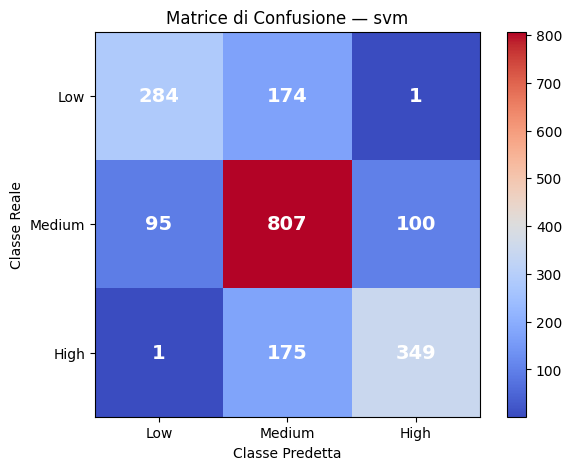

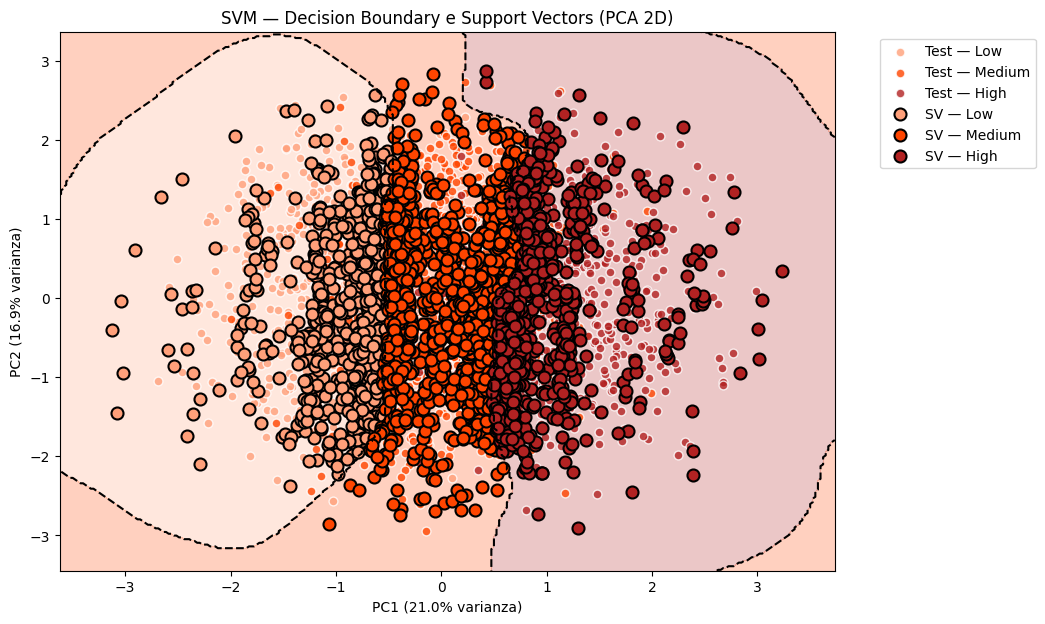

Varianza totale spiegata: 37.84%
Support Vectors per classe:
Low: 693 support vectors
Medium: 1279 support vectors
High: 767 support vectors
Totale: 2739 su 6015 esempi di training
(45.5% dei dati di training sono support vectors)


In [ ]:
grid = [
    {
        "svm__kernel": ['linear'],
        "svm__C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "svm__kernel": ['rbf'],
        "svm__C": [0.01, 0.1,1, 2, 10, 100],
        "svm__gamma": ['scale', 'auto', 0.01, 0.1,1,2,3, 10]
    }
]

Train_and_Test_GridSearch(svm_model,grid,'svm')

In questo caso abbiamo allenato il modello usando la grid_search e abbiamo ottenuto una accuratezza inferiore rispetto a prima ma come si può vedere nel gtrafico le divisioni tra classi seguono meglio i support vector.

#### Extreme Gradient Boosting (XGBoost)

**XGBoost** (Extreme Gradient Boosting) è un algoritmo che costruisce sequenzialmente un insieme di alberi decisionali, dove ogni nuovo albero impara a correggere gli errori commessi dai precedenti. Il risultato finale è la combinazione pesata di tutti gli alberi.

Gli iperparametri principali sono:

* **n_estimators**: Il numero di alberi da costruire nell'insieme. Valori più alti aumentano la capacità del modello ma incrementano il rischio di overfitting e i tempi di calcolo.
* **learning_rate** (eta): Determina il contributo di ogni albero alla predizione finale. Un valore basso rende l'apprendimento più lento e conservativo. Un valore alto accelera l'apprendimento ma può portare a overfitting.
* **max_depth**: La profondità massima di ogni albero. Alberi più profondi catturano relazioni più complesse nei dati ma tendono all'overfitting.
* **gamma**: La riduzione minima della perdita necessaria per effettuare un'ulteriore divisione su un nodo. Un valore basso permette più split, un valore alto li limita rendendo il modello più conservativo.

xgboost
Accuracy:74.87%
Precision:74.44%
Recall:75.63%
F1-score:74.99%
Tasso di errore:25.13%
Cohen's Kappa:60.01%
IC 95%:[72.92% — 76.73%]
              precision    recall  f1-score   support

         Low       0.73      0.78      0.75       459
      Medium       0.76      0.73      0.75      1002
        High       0.74      0.77      0.75       525

    accuracy                           0.75      1986
   macro avg       0.74      0.76      0.75      1986
weighted avg       0.75      0.75      0.75      1986



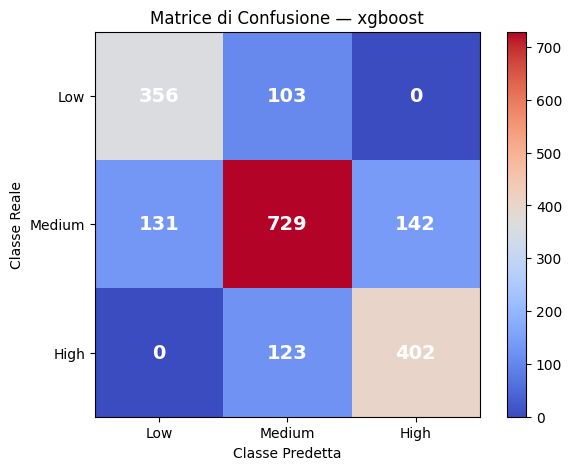

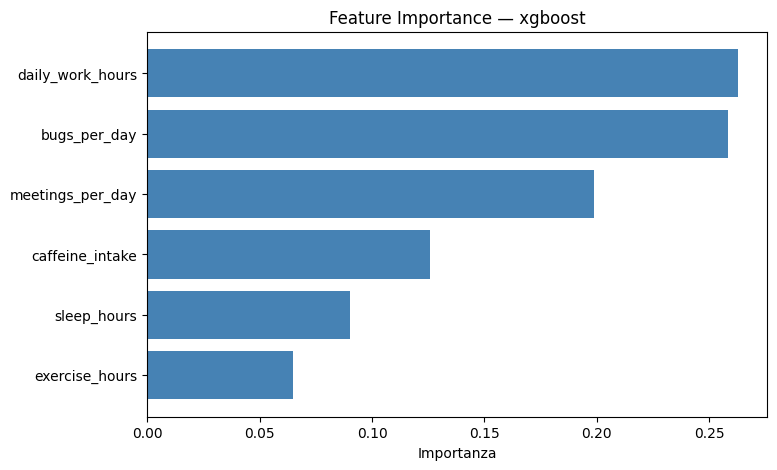

In [ ]:
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgboost', xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        random_state=42
    ))
])
Train_and_Test(xgb_pipeline, 'xgboost')

Dopo un allenamento del modello di default non notiamo nessun particolare degno di nota eccetto il miglioramento rispetto ai modelli più semplici e lineari

Migliori iperparametri per xgboost: {'xgboost__gamma': 0, 'xgboost__learning_rate': 0.1, 'xgboost__max_depth': 9, 'xgboost__n_estimators': 200}
xgboost
Accuracy:75.33%
Precision:75.03%
Recall:75.73%
F1-score:75.36%
Tasso di errore:24.67%
Cohen's Kappa:60.56%
IC 95%:[73.38% — 77.17%]
              precision    recall  f1-score   support

         Low       0.74      0.77      0.75       459
      Medium       0.76      0.74      0.75      1002
        High       0.75      0.76      0.75       525

    accuracy                           0.75      1986
   macro avg       0.75      0.76      0.75      1986
weighted avg       0.75      0.75      0.75      1986



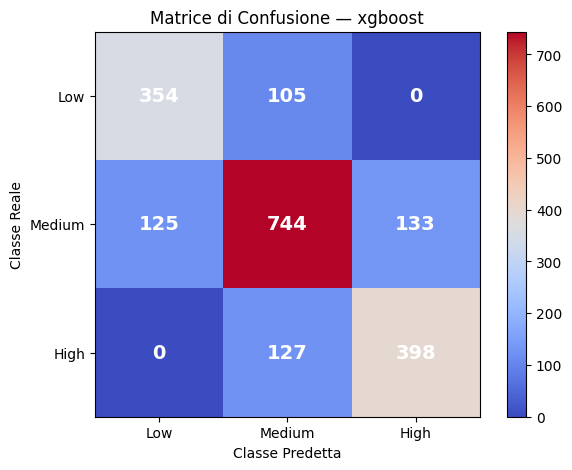

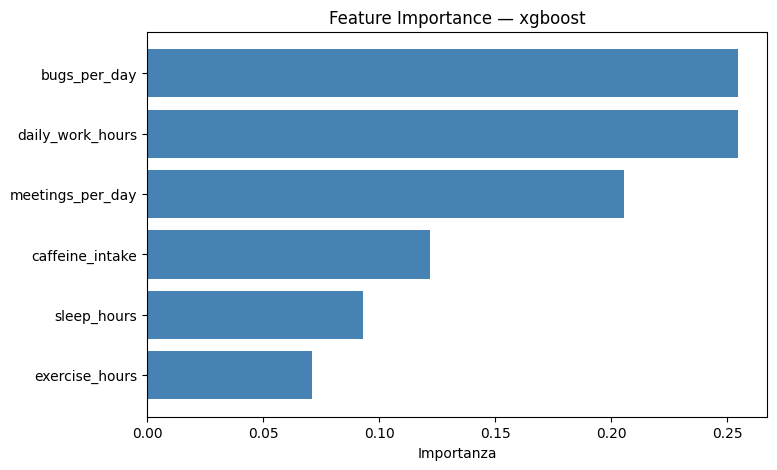

In [ ]:
grid_xgb = {
    'xgboost__n_estimators': [100, 200, 300],
    'xgboost__max_depth': [3, 6, 9],
    'xgboost__learning_rate': [0.01, 0.1, 0.3],
    'xgboost__gamma': [0, 1, 5]
}
Train_and_Test_GridSearch(xgb_pipeline, grid_xgb, 'xgboost')

Cercando i migliori iperparametri notiamo un leggero miglioramento nell'accuratezza e un peso leggermente maggiorato per la statistica dei **bugs_per_day**

#### Light Gradient Boosting Machine (LightGBM)

**LightGBM** (Light Gradient Boosting Machine) è un algoritmo sviluppato da Microsoft, concettualmente simile a XGBoost ma con differenze architetturali che lo rendono più veloce su dataset grandi. La differenza principale è che XGBoost costruisce gli alberi livello per livello (level-wise), mentre LightGBM li costruisce foglia per foglia (leaf-wise), concentrandosi sui rami che riducono maggiormente l'errore.
Gli iperparametri principali sono:

* **n_estimators**: Come in XGBoost, indica il numero di alberi nell'insieme. Stesso trade-off tra capacità e overfitting.
* **learning_rate**: Stesso ruolo di XGBoost: controlla il contributo di ogni albero. Va bilanciato con n_estimators.
* **max_depth**: Profondità massima degli alberi.
* **num_leaves**: Il parametro più caratteristico di LightGBM. Controlla il numero massimo di foglie per albero, determinando la complessità in modo più diretto di max_depth. Dovrebbe essere sempre minore di 2^max_depth per evitare overfitting.
* **min_child_samples**: Il numero minimo di campioni richiesti per creare un nodo foglia. Svolge un ruolo simile a gamma in XGBoost: valori più alti rendono il modello più conservativo e riducono il rischio di overfitting.

lightgbm
Accuracy:76.99%
Precision:76.61%
Recall:77.60%
F1-score:77.07%
Tasso di errore:23.01%
Cohen's Kappa:63.31%
IC 95%:[75.09% — 78.79%]
              precision    recall  f1-score   support

         Low       0.76      0.79      0.77       459
      Medium       0.78      0.75      0.77      1002
        High       0.76      0.78      0.77       525

    accuracy                           0.77      1986
   macro avg       0.77      0.78      0.77      1986
weighted avg       0.77      0.77      0.77      1986



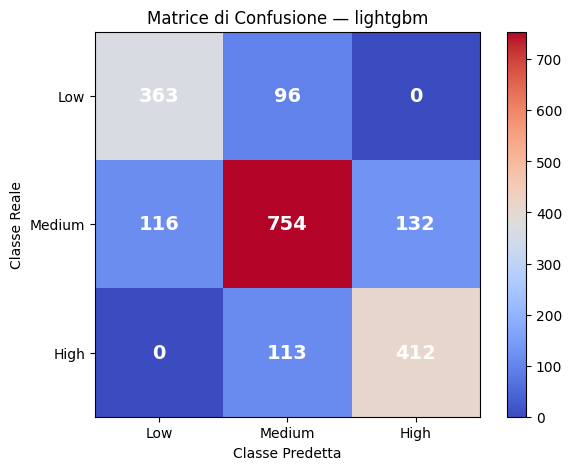

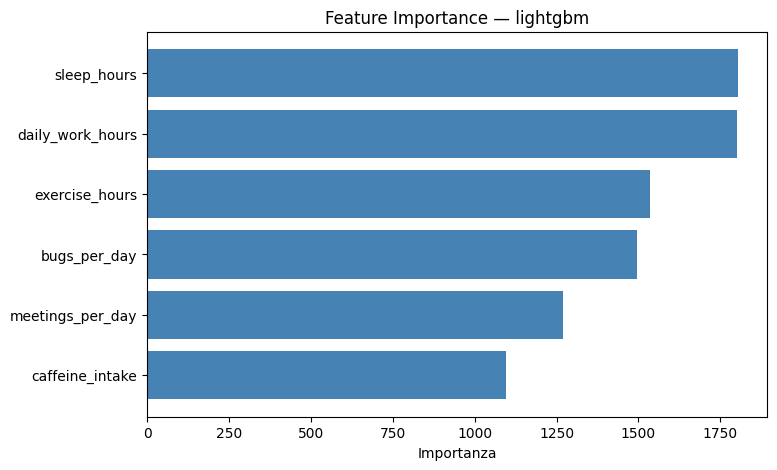

In [ ]:
lgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lightgbm', lgb.LGBMClassifier(
        objective='multiclass',
        num_class=3,
        random_state=42,
        verbose=-1
    ))
])
Train_and_Test(lgb_pipeline, 'lightgbm')

Il modello di default presenta una buona accuratezza e sorprendentemente dà una elevata importanza alla feature **sleep_hours**, cosa non vista nei modelli precedenti.

Migliori iperparametri per lightgbm: {'lightgbm__learning_rate': 0.1, 'lightgbm__max_depth': 9, 'lightgbm__min_child_samples': 10, 'lightgbm__n_estimators': 200, 'lightgbm__num_leaves': 31}
lightgbm
Accuracy:76.89%
Precision:76.48%
Recall:77.45%
F1-score:76.94%
Tasso di errore:23.11%
Cohen's Kappa:63.14%
IC 95%:[74.98% — 78.69%]
              precision    recall  f1-score   support

         Low       0.75      0.78      0.77       459
      Medium       0.78      0.75      0.77      1002
        High       0.77      0.79      0.78       525

    accuracy                           0.77      1986
   macro avg       0.76      0.77      0.77      1986
weighted avg       0.77      0.77      0.77      1986



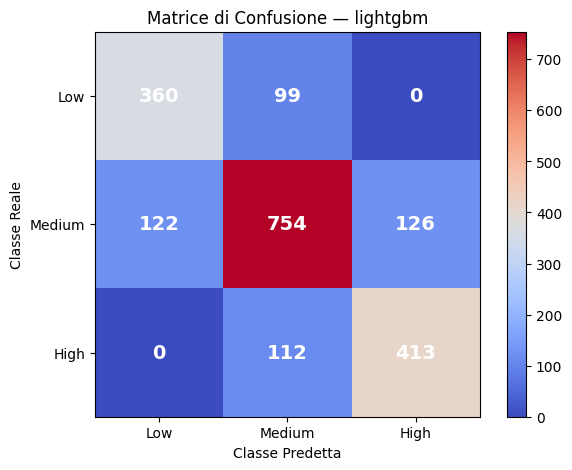

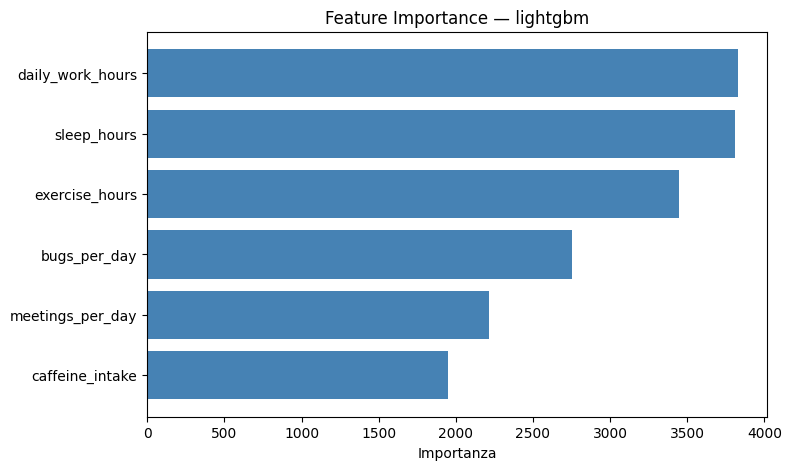

In [ ]:
grid_lgb = {
  'lightgbm__n_estimators':[100, 200, 300],
  'lightgbm__learning_rate':[0.01, 0.1, 0.3],
  'lightgbm__max_depth': [3, 6, 9],
  'lightgbm__min_child_samples': [10, 30, 50],
  'lightgbm__num_leaves': [15, 31, 63]
}
Train_and_Test_GridSearch(lgb_pipeline, grid_lgb, 'lightgbm')

Dopo la ricerca dei migliori iperparametri l'accuratezza resta stabile e notiamo un cambiamento dei pesi delle feature togliendo il predominio da **sleep_hours**

### 6. Confronti tra modelli

#### Nested Cross Validation

La **Nested Cross-Validation** utilizza due cicli di cross-validation: uno interno per ottimizzare gli iperparametri del modello e uno esterno per valutare le performance finali su dati indipendenti. Questo approccio garantisce una stima più robusta e imparziale delle capacità predittive del modello, evitando l'ottimismo che può derivare dalla valutazione sullo stesso set di dati usato per la selezione degli iperparametri.

In [ ]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv  = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

modelli_nested = {
    'perceptron': (
        ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('scaler', StandardScaler()),
            ('perceptron', Perceptron(max_iter=1000, random_state=42))
        ]),
        {'perceptron__penalty': [None, 'l2', 'l1','elasticnet'],
         'perceptron__alpha': [0.000001,0.00001,0.0001, 0.001, 0.01, 0.1, 1]}
    ),
    'lr': (
        ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(solver='saga', max_iter=1000, random_state=42))
        ]),
        [{'lr__penalty': [None]},
         {'lr__penalty': ['l2','l1'], 'lr__C': np.logspace(-2, 2, 5)},
         {'lr__penalty': ['elasticnet'], 'lr__C': np.logspace(-2, 2, 5),"lr__l1_ratio": [0.2, 0.5]}]
    ),
    'Ds': (
        ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('Ds', DecisionTreeClassifier(random_state=42))
        ]),
        {'Ds__max_depth': [1,2,3,4,5,6,7,8,9,10]}
    ),
    'svm': (
        ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('scaler', StandardScaler()),
            ('svm', SVC(random_state=42))
        ]),
        [{'svm__kernel': ['linear'], 'svm__C': [0.01, 0.1, 1, 10, 100]},
         {'svm__kernel': ['rbf'], 'svm__C': [0.01, 0.1,1, 2, 10, 100],
          'svm__gamma': ['scale', 'auto', 0.01, 0.1,1,2,3, 10]}]
    ),
    'xgboost': (
        ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('xgboost', xgb.XGBClassifier(objective='multi:softmax',
                                           num_class=3, random_state=42))
        ]),
        {'xgboost__n_estimators': [100, 200, 300],
         'xgboost__max_depth': [3, 6, 9],
         'xgboost__learning_rate': [0.01, 0.1, 0.3],
         'xgboost__gamma': [0, 1, 5]}
    ),
    'lightgbm': (
        ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('lightgbm', lgb.LGBMClassifier(objective='multiclass',
                                             num_class=3, random_state=42))
        ]),
        {'lightgbm__n_estimators': [100, 200, 300],
         'lightgbm__learning_rate': [0.01, 0.1, 0.3],
         'lightgbm__max_depth': [3, 6, 9],
         'lightgbm__min_child_samples': [10, 30, 50],
         'lightgbm__num_leaves': [15, 31, 63]}
    ),
}

risultati_nested = {}
for nome, (pipeline, grid) in modelli_nested.items():
    scores = []
    best_params_per_fold = []

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(Dati_Rilevanti, Dati_Label_Mappati)):
        X_train_fold = Dati_Rilevanti.iloc[train_idx]
        y_train_fold = Dati_Label_Mappati.iloc[train_idx]
        X_test_fold  = Dati_Rilevanti.iloc[test_idx]
        y_test_fold  = Dati_Label_Mappati.iloc[test_idx]

        gs = GridSearchCV(pipeline, grid, cv=inner_cv,
                          scoring='accuracy', n_jobs=-1)
        gs.fit(X_train_fold, y_train_fold)

        score = gs.score(X_test_fold, y_test_fold)
        scores.append(score)
        best_params_per_fold.append(gs.best_params_)

        print(f"  Fold {fold_idx+1}: accuracy={score:.4f} | params={gs.best_params_}")

    scores = np.array(scores)
    risultati_nested[nome] = scores
    print(f"{nome:20s} → accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
    print()

  Fold 1: accuracy=0.6795 | params={'perceptron__alpha': 0.0001, 'perceptron__penalty': 'l1'}
  Fold 2: accuracy=0.7458 | params={'perceptron__alpha': 0.001, 'perceptron__penalty': 'l1'}
  Fold 3: accuracy=0.7022 | params={'perceptron__alpha': 0.001, 'perceptron__penalty': 'elasticnet'}
  Fold 4: accuracy=0.7708 | params={'perceptron__alpha': 0.001, 'perceptron__penalty': 'elasticnet'}
  Fold 5: accuracy=0.7011 | params={'perceptron__alpha': 0.0001, 'perceptron__penalty': 'l1'}
perceptron           → accuracy: 0.7199 ± 0.0333

  Fold 1: accuracy=0.7987 | params={'lr__C': np.float64(1.0), 'lr__l1_ratio': 0.5, 'lr__penalty': 'elasticnet'}
  Fold 2: accuracy=0.7760 | params={'lr__penalty': None}
  Fold 3: accuracy=0.7836 | params={'lr__penalty': None}
  Fold 4: accuracy=0.7825 | params={'lr__C': np.float64(1.0), 'lr__penalty': 'l1'}
  Fold 5: accuracy=0.7750 | params={'lr__C': np.float64(1.0), 'lr__penalty': 'l1'}
lr                   → accuracy: 0.7831 ± 0.0085

  Fold 1: accuracy=0.7039

Dai risultati vediamo come il miglior modello sia **SVM**, come ci si aspettava.
In particolare vediamo non solo una accuratezza alta ma anche una buona stabilità nella scelta dei migliori iperparametri cosa che indica robustezza e affidabilità del modello.
Per quanto riguarda gli altri modelli:
*  **Perceptron**: Modello con una bassa accuratezza e poca stabilità.
* **Lr**: Modello con una buona accuratezza ma poca stabilità.
* **Ds**: Modello con una bassa accuratezza ma alta stabilità.
* **XGBoost**: Modello con una buona accuratezza e stabilità media.
* **LightGBM**: Modello con una buona accuratezza e stabilità media.

### Confronto a coppie

Come ultima cosa confrontiamo a coppie tutti i modelli per osservare se la differenza tra essi è significativa oppure trascurabile

In [ ]:
def confronta_modelli(modelli_dict):
  nomi = list(modelli_dict.keys())

  print("Accuracy sul test set")
  accuracies = {}
  for nome, pred in modelli_dict.items():
    acc = accuracy_score(Dati_Label_Test, pred)
    accuracies[nome] = acc
    print(f"{nome}: {acc:.2%}")

  print("\n\nConfronto a coppie")
  Z = 1.96

  for m1, m2 in combinations(nomi, 2):
    pred1 = modelli_dict[m1]
    pred2 = modelli_dict[m2]
    y = Dati_Label_Test.values
    n = len(y)
    correct1 = (pred1 == y)
    correct2 = (pred2 == y)

    a = np.sum( correct1 &  correct2)
    b = np.sum( correct1 & ~correct2)
    c = np.sum(~correct1 &  correct2)
    d = np.sum(~correct1 & ~correct2)
    contingency = np.array([[a, b], [c, d]])

    print(f"{m1} vs {m2}")
    plt.figure(figsize=(7, 5))
    plt.imshow(contingency, cmap='coolwarm')
    plt.colorbar()
    plt.xticks([0, 1], ['Corretti', 'Sbagliati'])
    plt.yticks([0, 1], ['Corretti', 'Sbagliati'])
    plt.xlabel(''+m2)
    plt.ylabel(''+m1)
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(contingency[i, j]), ha='center', va='center',
                     color='white', fontsize=14, fontweight='bold')
    plt.show()

    result = mcnemar(contingency, exact=False)

    e1 = 1 - accuracies[m1]
    e2 = 1 - accuracies[m2]
    d_obs = e1 - e2
    sigma_t = np.sqrt(e1*(1-e1)/n + e2*(1-e2)/n)
    ic_min = d_obs - Z * sigma_t
    ic_max = d_obs + Z * sigma_t


    print(f"McNemar — X²={result.statistic:.3f}, p-value={result.pvalue:.3f}")
    if result.pvalue > 0.05:
        print(f"→ I modelli sono equivalenti (p > 0.05)")
    else:
        print(f"→ I modelli sono significativamente diversi (p ≤ 0.05)")
    print(f"Diff errori (e1-e2): {d_obs:+.4f}")
    print(f"IC 95% differenza: [{ic_min:+.4f}, {ic_max:+.4f}]")
    if ic_min > 0:
        print(f"→ {m2} è significativamente migliore di {m1}\n")
    elif ic_max < 0:
        print(f"→ {m1} è significativamente migliore di {m2}\n")
    else:
        print(f"→ Differenza non conclusiva (IC contiene 0)\n")

Accuracy sul test set
perceptron: 63.85%
perceptron (GS): 67.98%
lr: 78.20%
lr (GS): 78.05%
Ds: 67.82%
Ds (GS): 69.03%
svm: 77.54%
svm (GS): 72.51%
xgboost: 74.87%
xgboost (GS): 75.33%
lightgbm: 76.99%
lightgbm (GS): 76.89%


Confronto a coppie
perceptron vs perceptron (GS)


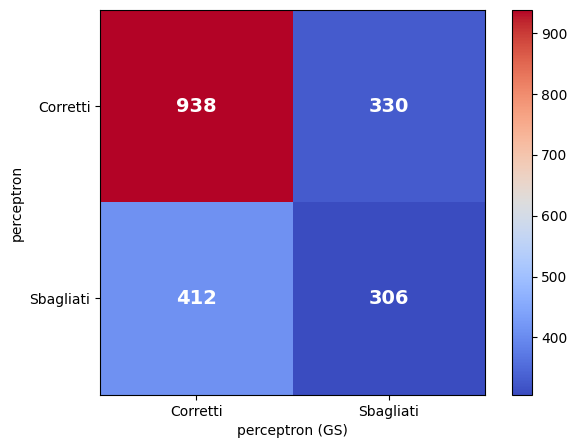

McNemar — X²=8.842, p-value=0.003
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0413
IC 95% differenza: [+0.0118, +0.0707]
→ perceptron (GS) è significativamente migliore di perceptron

perceptron vs lr


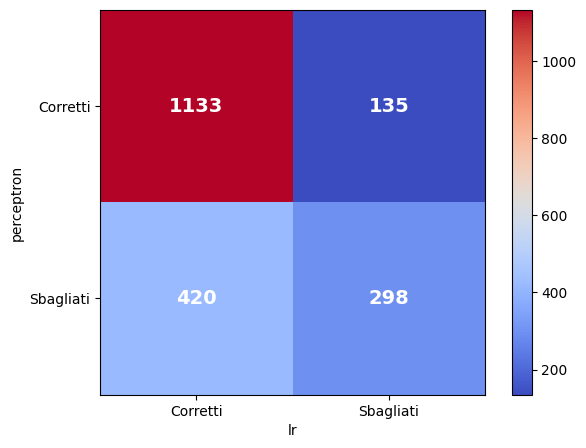

McNemar — X²=145.326, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.1435
IC 95% differenza: [+0.1156, +0.1714]
→ lr è significativamente migliore di perceptron

perceptron vs lr (GS)


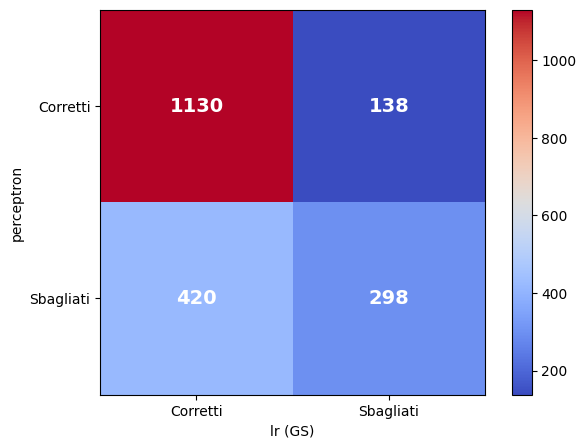

McNemar — X²=141.507, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.1420
IC 95% differenza: [+0.1141, +0.1699]
→ lr (GS) è significativamente migliore di perceptron

perceptron vs Ds


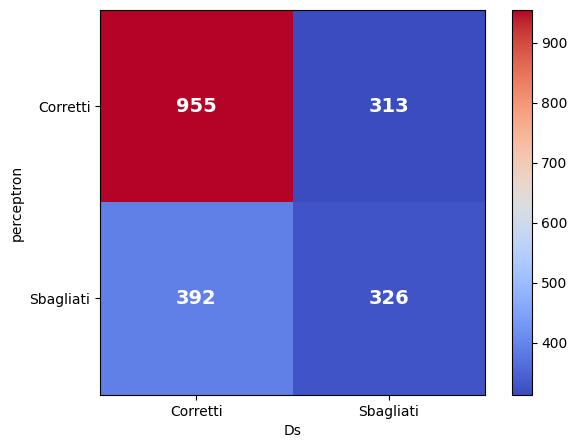

McNemar — X²=8.630, p-value=0.003
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0398
IC 95% differenza: [+0.0103, +0.0693]
→ Ds è significativamente migliore di perceptron

perceptron vs Ds (GS)


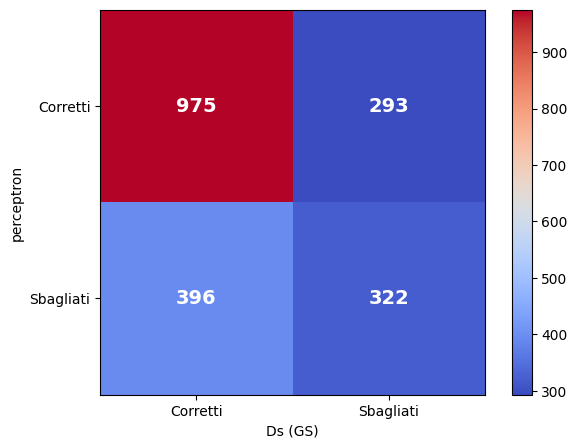

McNemar — X²=15.100, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0519
IC 95% differenza: [+0.0225, +0.0812]
→ Ds (GS) è significativamente migliore di perceptron

perceptron vs svm


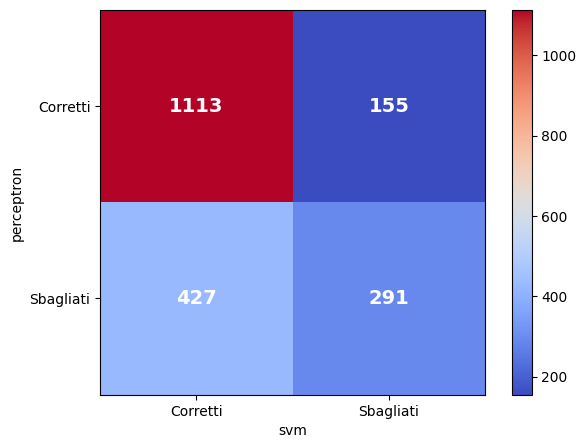

McNemar — X²=126.187, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.1370
IC 95% differenza: [+0.1090, +0.1649]
→ svm è significativamente migliore di perceptron

perceptron vs svm (GS)


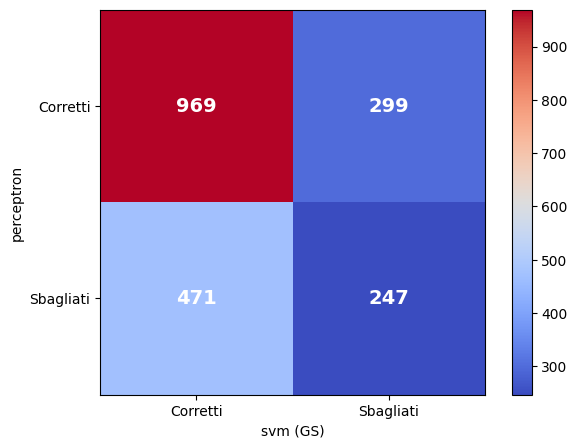

McNemar — X²=37.975, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0866
IC 95% differenza: [+0.0578, +0.1155]
→ svm (GS) è significativamente migliore di perceptron

perceptron vs xgboost


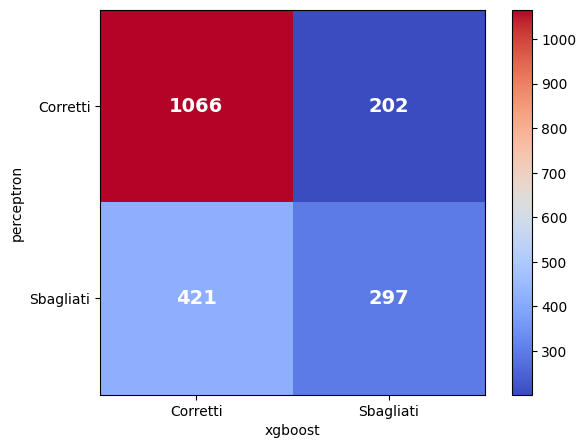

McNemar — X²=76.283, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.1103
IC 95% differenza: [+0.0818, +0.1387]
→ xgboost è significativamente migliore di perceptron

perceptron vs xgboost (GS)


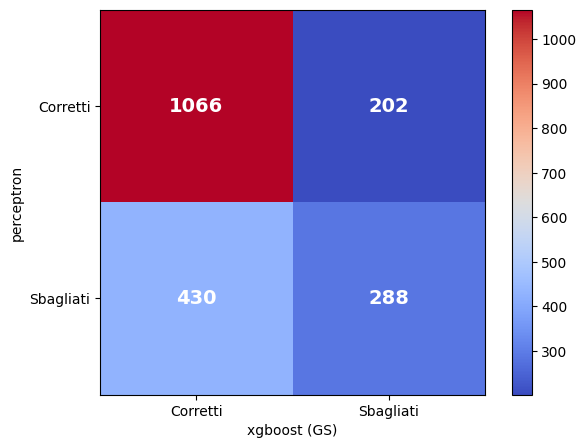

McNemar — X²=81.533, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.1148
IC 95% differenza: [+0.0864, +0.1432]
→ xgboost (GS) è significativamente migliore di perceptron

perceptron vs lightgbm


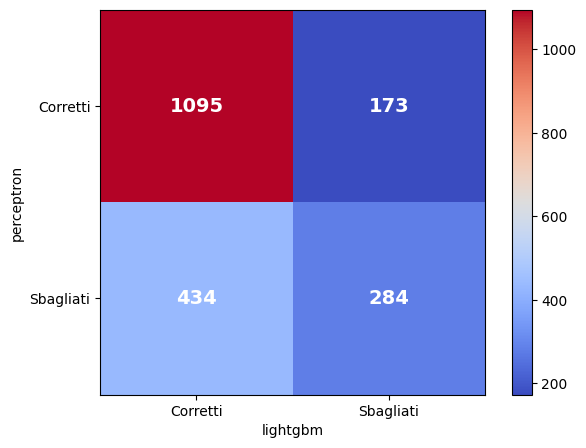

McNemar — X²=111.367, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.1314
IC 95% differenza: [+0.1033, +0.1595]
→ lightgbm è significativamente migliore di perceptron

perceptron vs lightgbm (GS)


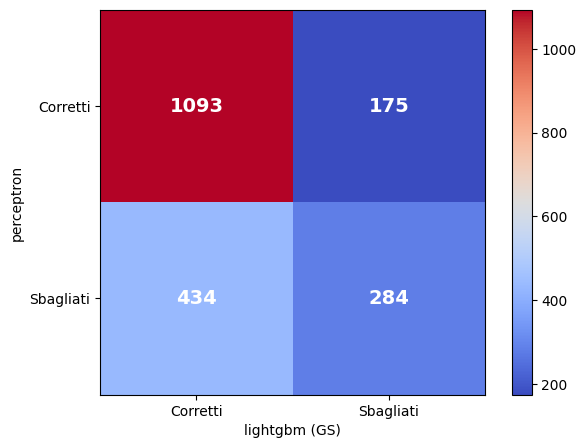

McNemar — X²=109.300, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.1304
IC 95% differenza: [+0.1023, +0.1585]
→ lightgbm (GS) è significativamente migliore di perceptron

perceptron (GS) vs lr


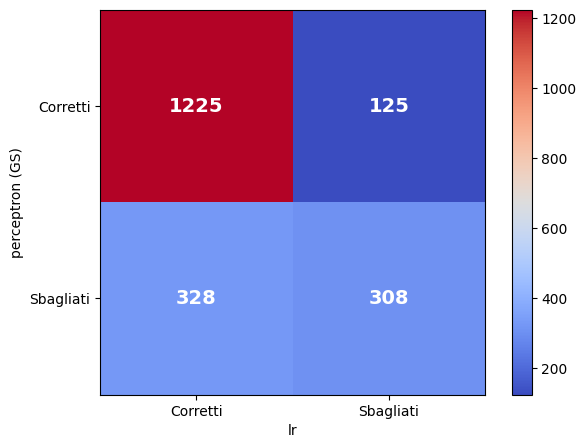

McNemar — X²=90.075, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.1022
IC 95% differenza: [+0.0748, +0.1296]
→ lr è significativamente migliore di perceptron (GS)

perceptron (GS) vs lr (GS)


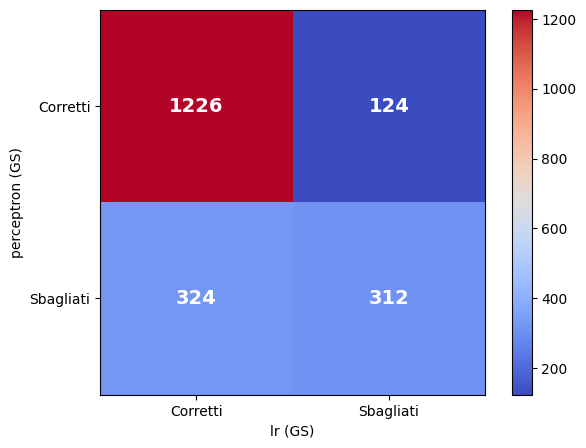

McNemar — X²=88.395, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.1007
IC 95% differenza: [+0.0733, +0.1281]
→ lr (GS) è significativamente migliore di perceptron (GS)

perceptron (GS) vs Ds


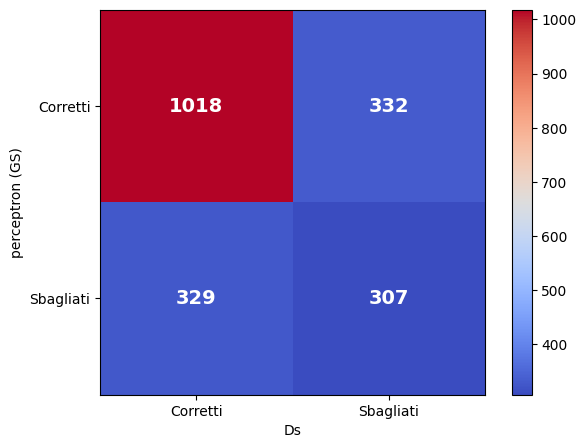

McNemar — X²=0.006, p-value=0.938
→ I modelli sono equivalenti (p > 0.05)
Diff errori (e1-e2): -0.0015
IC 95% differenza: [-0.0305, +0.0275]
→ Differenza non conclusiva (IC contiene 0)

perceptron (GS) vs Ds (GS)


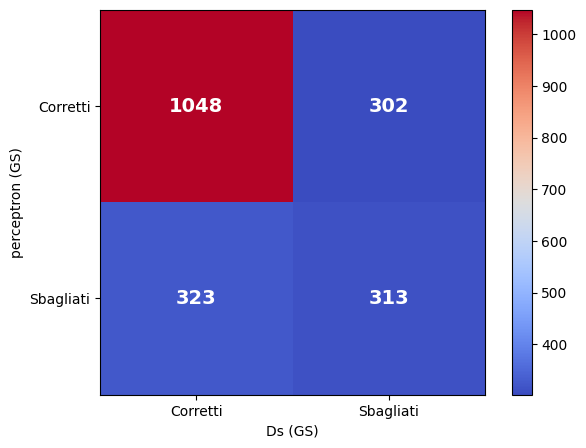

McNemar — X²=0.640, p-value=0.424
→ I modelli sono equivalenti (p > 0.05)
Diff errori (e1-e2): +0.0106
IC 95% differenza: [-0.0183, +0.0395]
→ Differenza non conclusiva (IC contiene 0)

perceptron (GS) vs svm


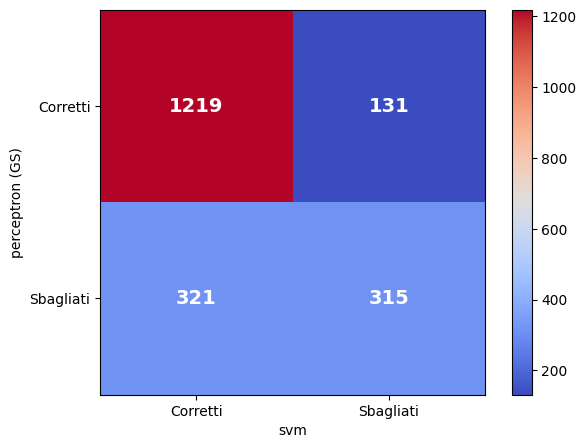

McNemar — X²=79.029, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0957
IC 95% differenza: [+0.0681, +0.1232]
→ svm è significativamente migliore di perceptron (GS)

perceptron (GS) vs svm (GS)


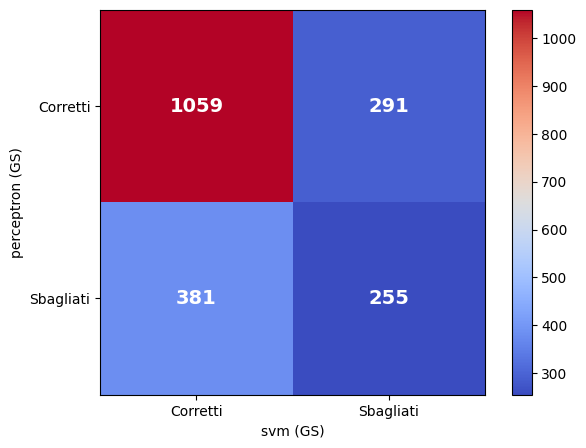

McNemar — X²=11.787, p-value=0.001
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0453
IC 95% differenza: [+0.0169, +0.0737]
→ svm (GS) è significativamente migliore di perceptron (GS)

perceptron (GS) vs xgboost


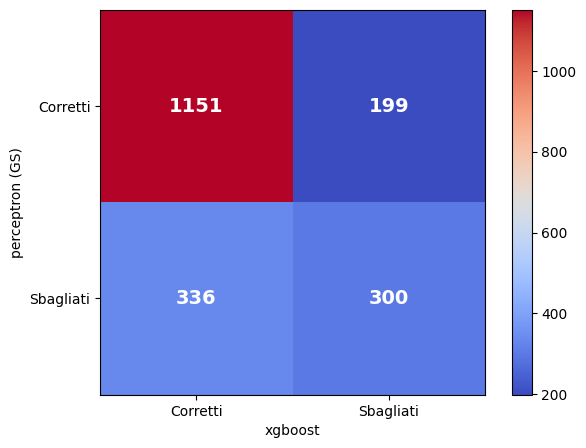

McNemar — X²=34.572, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0690
IC 95% differenza: [+0.0410, +0.0970]
→ xgboost è significativamente migliore di perceptron (GS)

perceptron (GS) vs xgboost (GS)


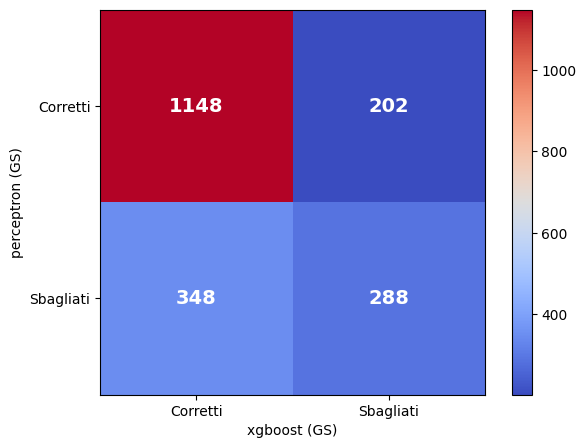

McNemar — X²=38.227, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0735
IC 95% differenza: [+0.0456, +0.1015]
→ xgboost (GS) è significativamente migliore di perceptron (GS)

perceptron (GS) vs lightgbm


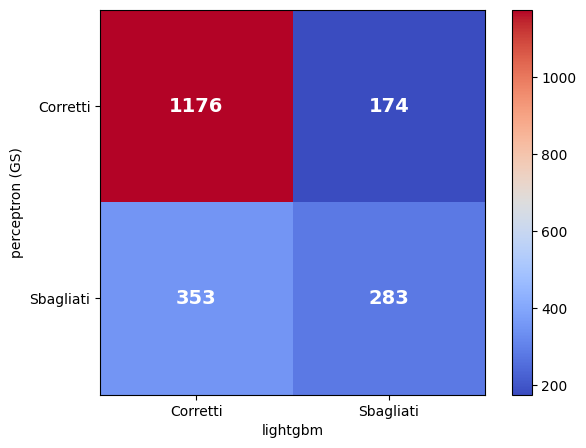

McNemar — X²=60.121, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0901
IC 95% differenza: [+0.0625, +0.1178]
→ lightgbm è significativamente migliore di perceptron (GS)

perceptron (GS) vs lightgbm (GS)


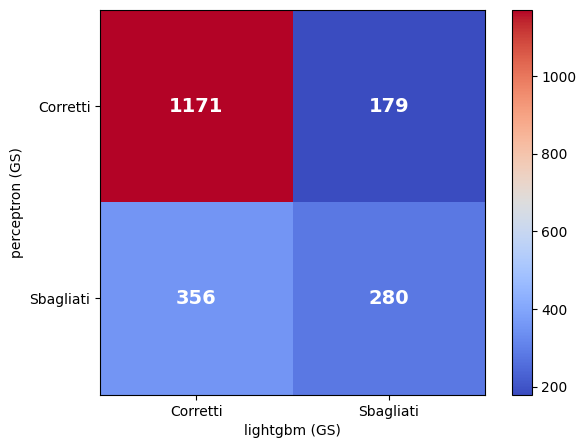

McNemar — X²=57.899, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0891
IC 95% differenza: [+0.0615, +0.1168]
→ lightgbm (GS) è significativamente migliore di perceptron (GS)

lr vs lr (GS)


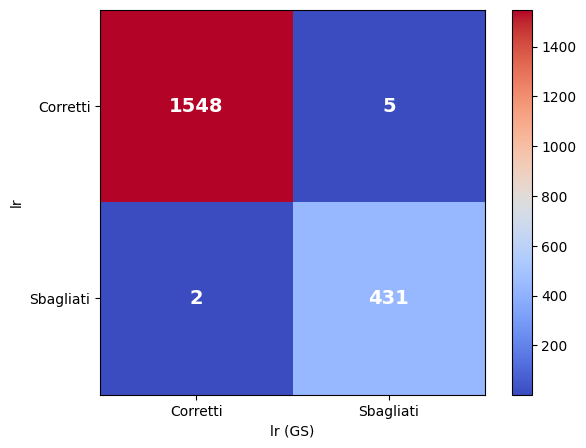

McNemar — X²=0.571, p-value=0.450
→ I modelli sono equivalenti (p > 0.05)
Diff errori (e1-e2): -0.0015
IC 95% differenza: [-0.0272, +0.0242]
→ Differenza non conclusiva (IC contiene 0)

lr vs Ds


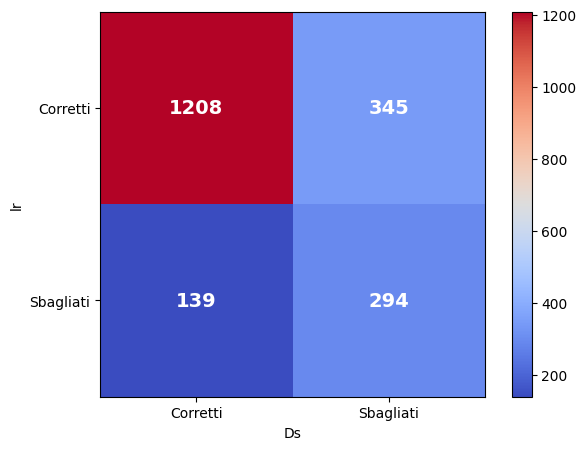

McNemar — X²=86.829, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): -0.1037
IC 95% differenza: [-0.1311, -0.0763]
→ lr è significativamente migliore di Ds

lr vs Ds (GS)


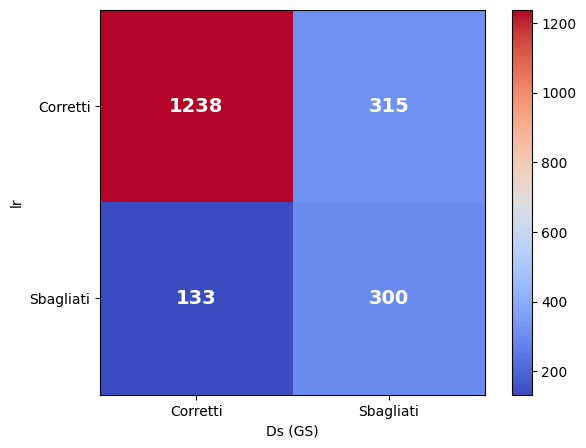

McNemar — X²=73.127, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): -0.0916
IC 95% differenza: [-0.1189, -0.0644]
→ lr è significativamente migliore di Ds (GS)

lr vs svm


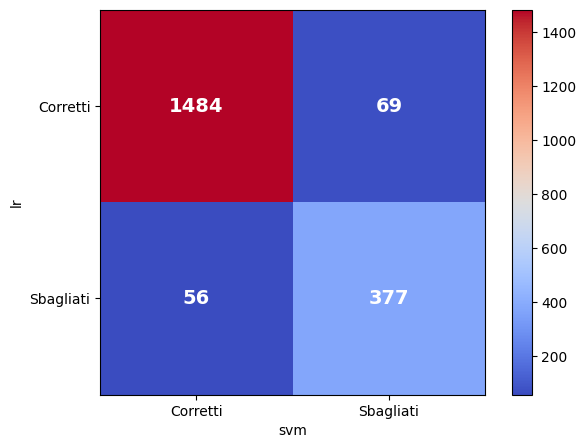

McNemar — X²=1.152, p-value=0.283
→ I modelli sono equivalenti (p > 0.05)
Diff errori (e1-e2): -0.0065
IC 95% differenza: [-0.0324, +0.0193]
→ Differenza non conclusiva (IC contiene 0)

lr vs svm (GS)


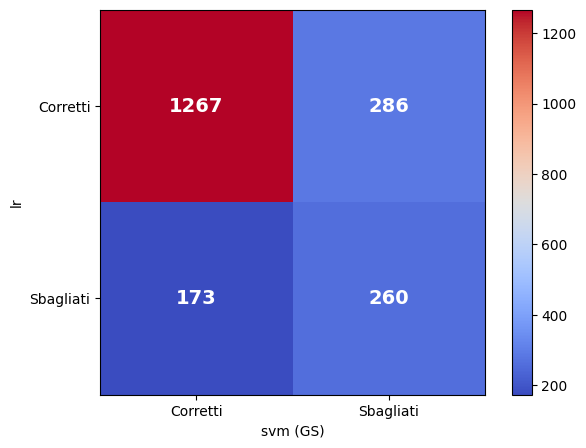

McNemar — X²=27.329, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): -0.0569
IC 95% differenza: [-0.0836, -0.0302]
→ lr è significativamente migliore di svm (GS)

lr vs xgboost


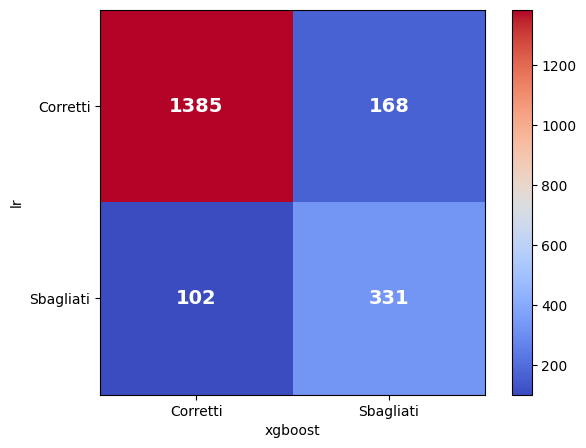

McNemar — X²=15.648, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): -0.0332
IC 95% differenza: [-0.0596, -0.0069]
→ lr è significativamente migliore di xgboost

lr vs xgboost (GS)


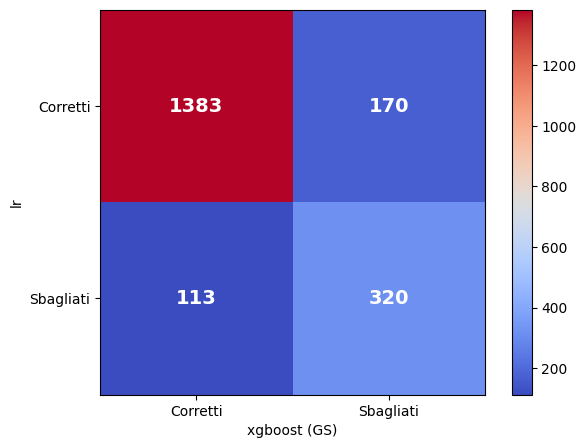

McNemar — X²=11.081, p-value=0.001
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): -0.0287
IC 95% differenza: [-0.0550, -0.0024]
→ lr è significativamente migliore di xgboost (GS)

lr vs lightgbm


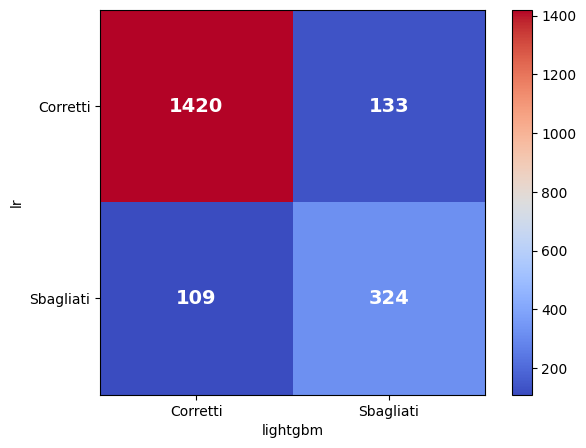

McNemar — X²=2.186, p-value=0.139
→ I modelli sono equivalenti (p > 0.05)
Diff errori (e1-e2): -0.0121
IC 95% differenza: [-0.0380, +0.0138]
→ Differenza non conclusiva (IC contiene 0)

lr vs lightgbm (GS)


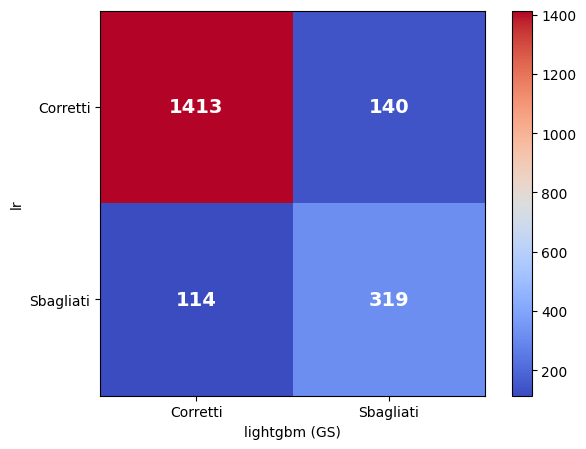

McNemar — X²=2.461, p-value=0.117
→ I modelli sono equivalenti (p > 0.05)
Diff errori (e1-e2): -0.0131
IC 95% differenza: [-0.0390, +0.0129]
→ Differenza non conclusiva (IC contiene 0)

lr (GS) vs Ds


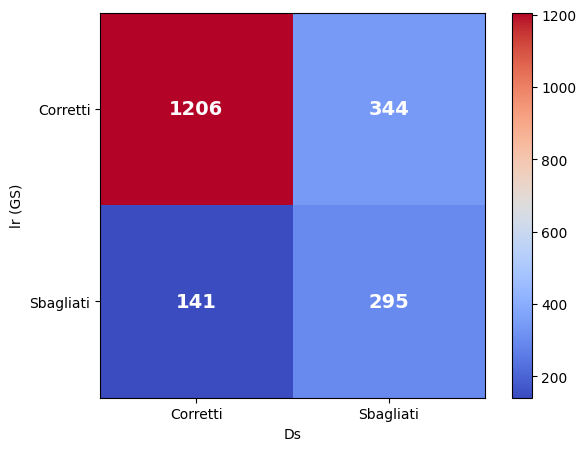

McNemar — X²=84.132, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): -0.1022
IC 95% differenza: [-0.1297, -0.0748]
→ lr (GS) è significativamente migliore di Ds

lr (GS) vs Ds (GS)


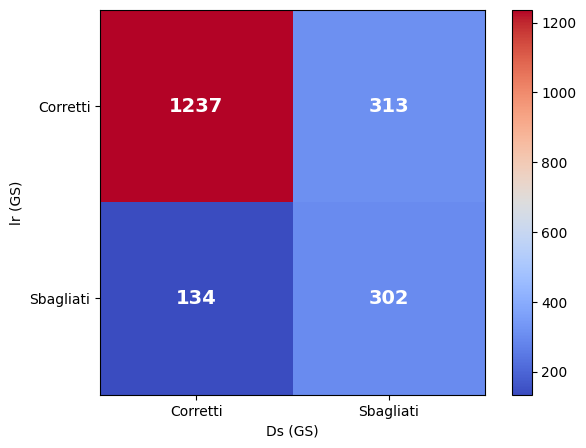

McNemar — X²=70.881, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): -0.0901
IC 95% differenza: [-0.1174, -0.0628]
→ lr (GS) è significativamente migliore di Ds (GS)

lr (GS) vs svm


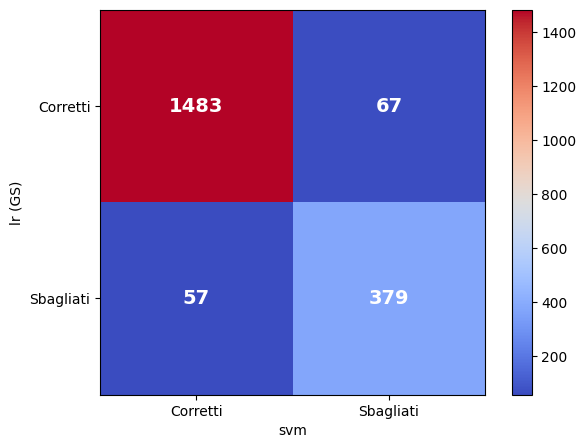

McNemar — X²=0.653, p-value=0.419
→ I modelli sono equivalenti (p > 0.05)
Diff errori (e1-e2): -0.0050
IC 95% differenza: [-0.0309, +0.0208]
→ Differenza non conclusiva (IC contiene 0)

lr (GS) vs svm (GS)


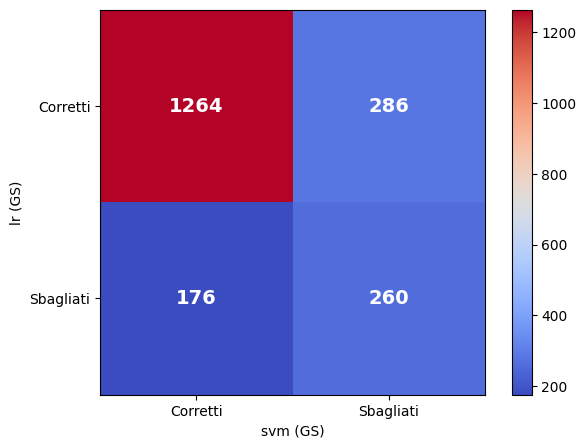

McNemar — X²=25.716, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): -0.0554
IC 95% differenza: [-0.0822, -0.0286]
→ lr (GS) è significativamente migliore di svm (GS)

lr (GS) vs xgboost


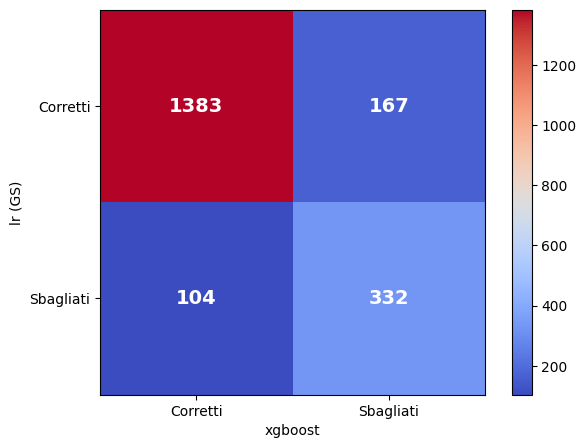

McNemar — X²=14.185, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): -0.0317
IC 95% differenza: [-0.0581, -0.0054]
→ lr (GS) è significativamente migliore di xgboost

lr (GS) vs xgboost (GS)


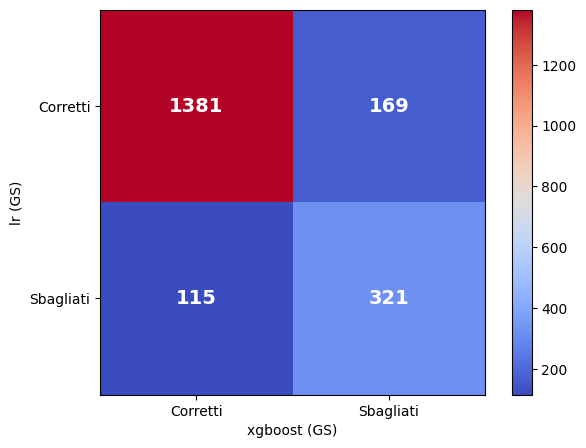

McNemar — X²=9.891, p-value=0.002
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): -0.0272
IC 95% differenza: [-0.0535, -0.0009]
→ lr (GS) è significativamente migliore di xgboost (GS)

lr (GS) vs lightgbm


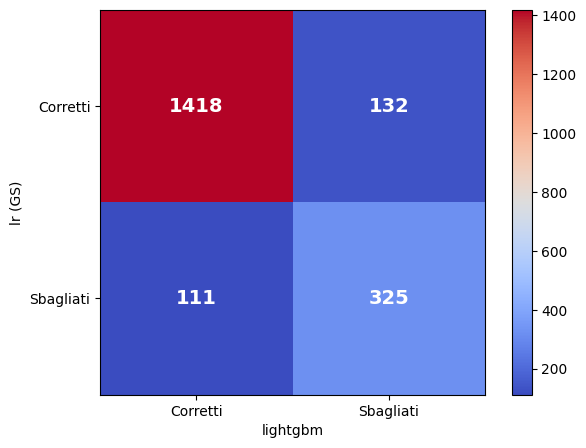

McNemar — X²=1.646, p-value=0.199
→ I modelli sono equivalenti (p > 0.05)
Diff errori (e1-e2): -0.0106
IC 95% differenza: [-0.0365, +0.0154]
→ Differenza non conclusiva (IC contiene 0)

lr (GS) vs lightgbm (GS)


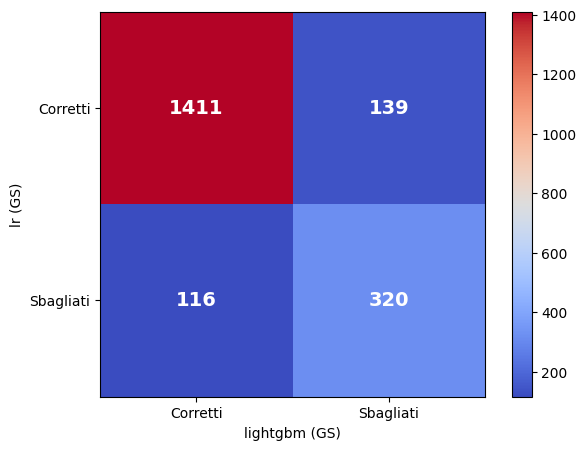

McNemar — X²=1.898, p-value=0.168
→ I modelli sono equivalenti (p > 0.05)
Diff errori (e1-e2): -0.0116
IC 95% differenza: [-0.0376, +0.0144]
→ Differenza non conclusiva (IC contiene 0)

Ds vs Ds (GS)


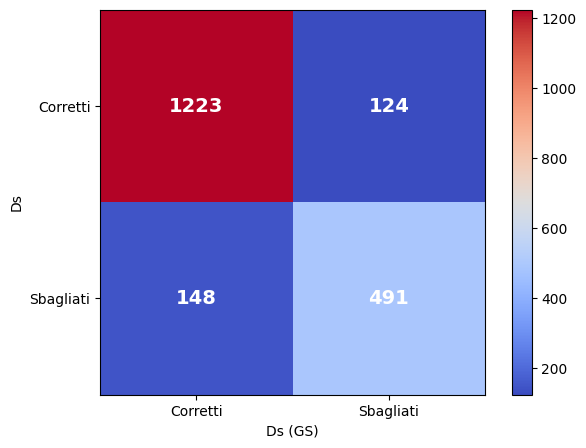

McNemar — X²=1.945, p-value=0.163
→ I modelli sono equivalenti (p > 0.05)
Diff errori (e1-e2): +0.0121
IC 95% differenza: [-0.0168, +0.0410]
→ Differenza non conclusiva (IC contiene 0)

Ds vs svm


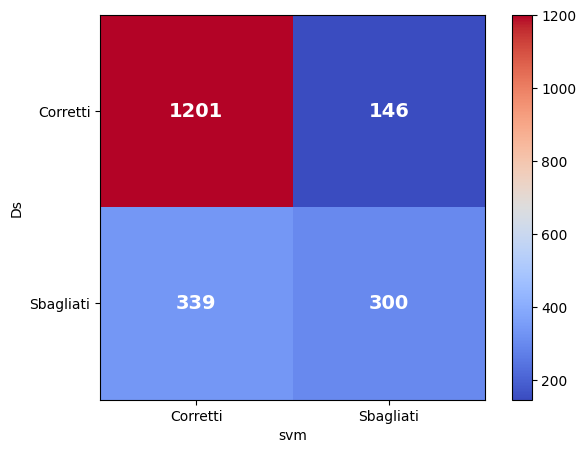

McNemar — X²=76.008, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0972
IC 95% differenza: [+0.0696, +0.1247]
→ svm è significativamente migliore di Ds

Ds vs svm (GS)


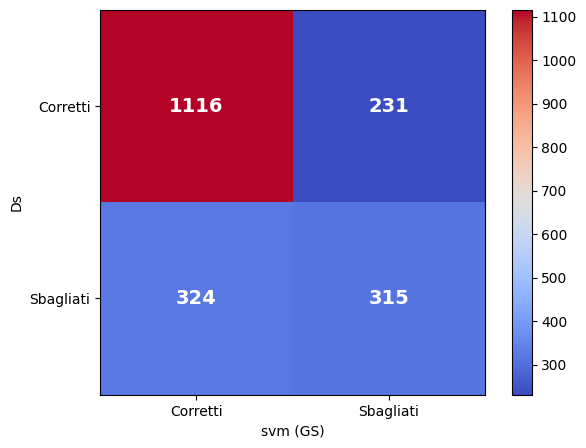

McNemar — X²=15.250, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0468
IC 95% differenza: [+0.0184, +0.0752]
→ svm (GS) è significativamente migliore di Ds

Ds vs xgboost


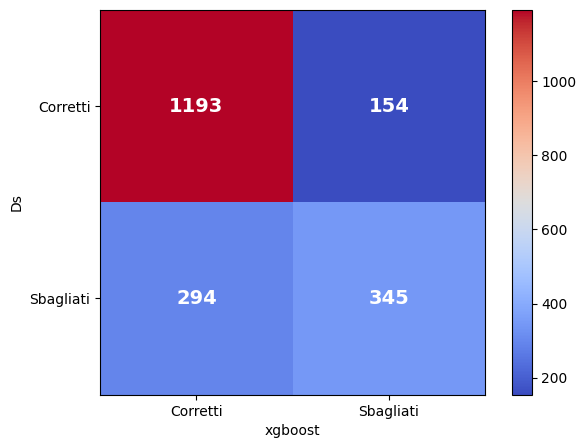

McNemar — X²=43.127, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0705
IC 95% differenza: [+0.0425, +0.0985]
→ xgboost è significativamente migliore di Ds

Ds vs xgboost (GS)


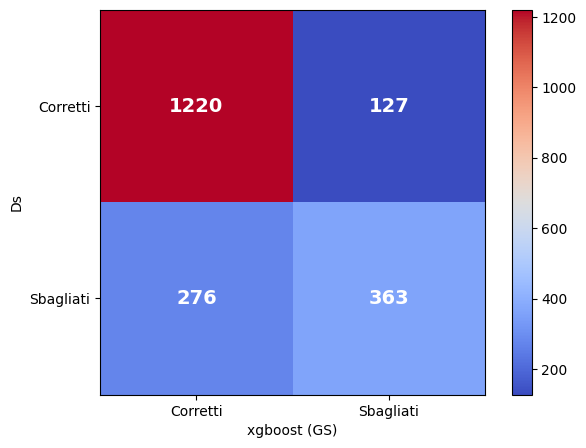

McNemar — X²=54.352, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0750
IC 95% differenza: [+0.0471, +0.1030]
→ xgboost (GS) è significativamente migliore di Ds

Ds vs lightgbm


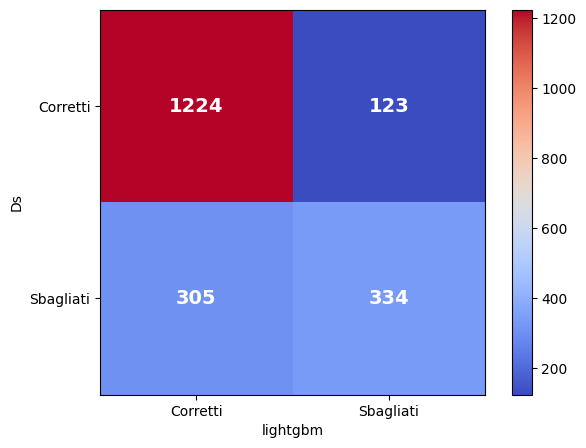

McNemar — X²=76.544, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0916
IC 95% differenza: [+0.0640, +0.1193]
→ lightgbm è significativamente migliore di Ds

Ds vs lightgbm (GS)


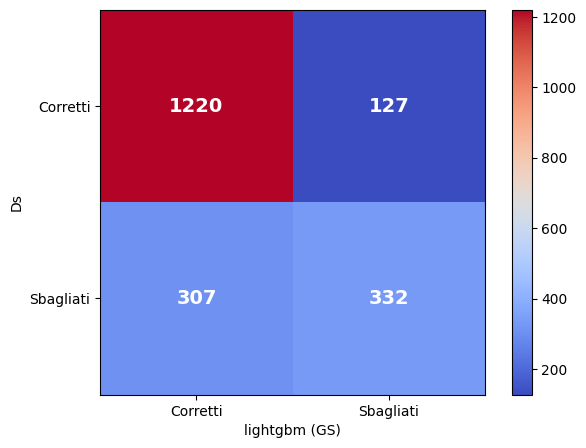

McNemar — X²=73.827, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0906
IC 95% differenza: [+0.0630, +0.1183]
→ lightgbm (GS) è significativamente migliore di Ds

Ds (GS) vs svm


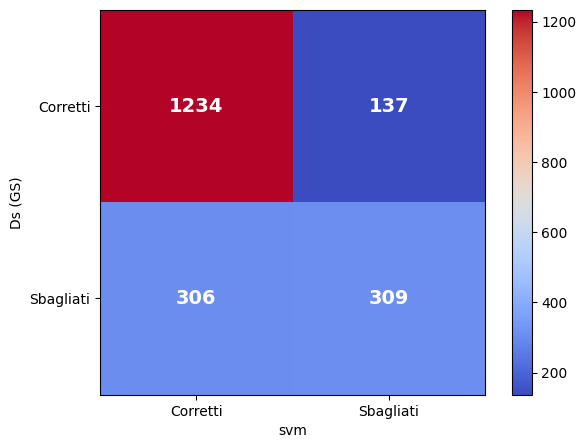

McNemar — X²=63.711, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0851
IC 95% differenza: [+0.0577, +0.1125]
→ svm è significativamente migliore di Ds (GS)

Ds (GS) vs svm (GS)


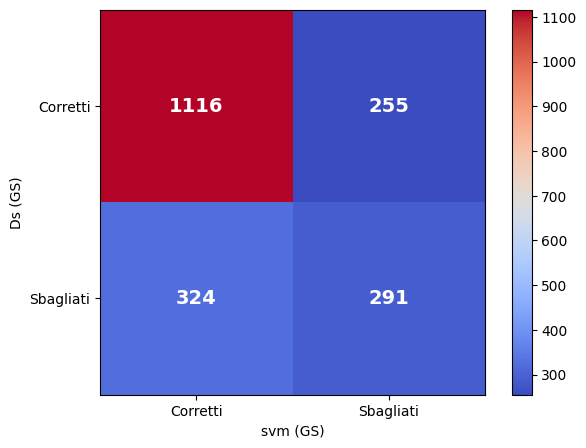

McNemar — X²=7.986, p-value=0.005
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0347
IC 95% differenza: [+0.0065, +0.0630]
→ svm (GS) è significativamente migliore di Ds (GS)

Ds (GS) vs xgboost


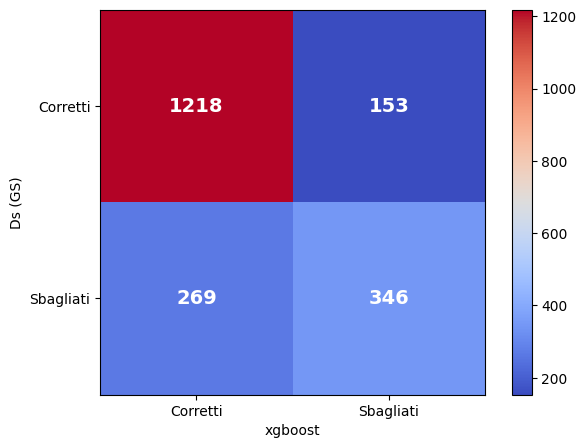

McNemar — X²=31.339, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0584
IC 95% differenza: [+0.0305, +0.0863]
→ xgboost è significativamente migliore di Ds (GS)

Ds (GS) vs xgboost (GS)


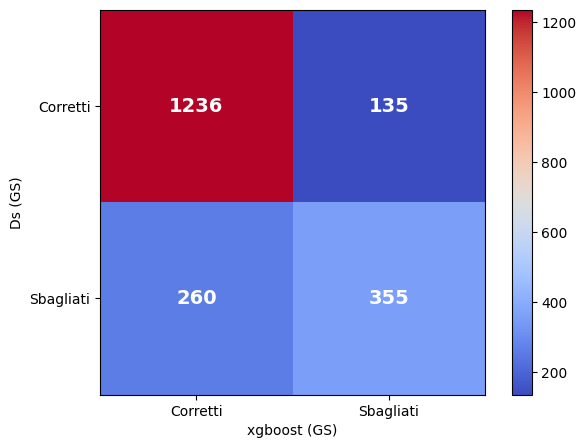

McNemar — X²=38.927, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0629
IC 95% differenza: [+0.0351, +0.0907]
→ xgboost (GS) è significativamente migliore di Ds (GS)

Ds (GS) vs lightgbm


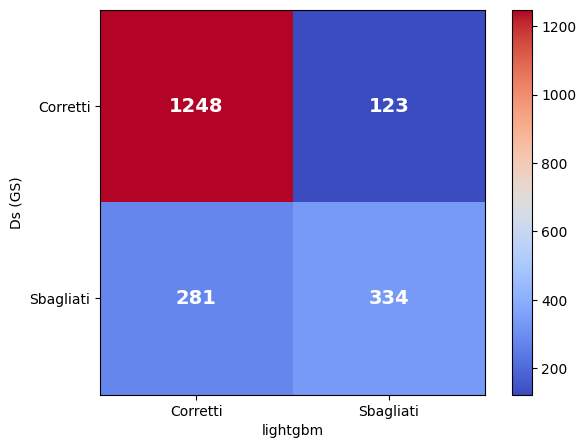

McNemar — X²=61.012, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0796
IC 95% differenza: [+0.0521, +0.1071]
→ lightgbm è significativamente migliore di Ds (GS)

Ds (GS) vs lightgbm (GS)


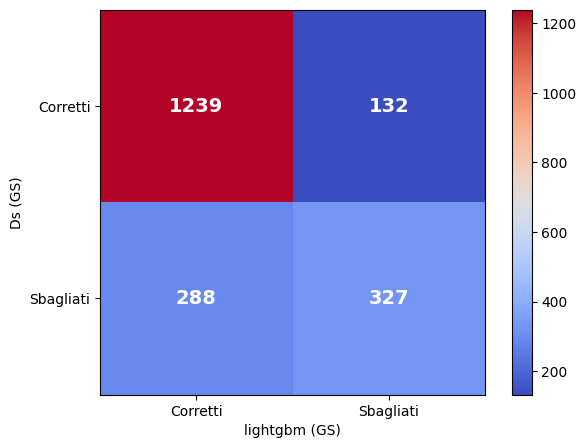

McNemar — X²=57.202, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0785
IC 95% differenza: [+0.0510, +0.1061]
→ lightgbm (GS) è significativamente migliore di Ds (GS)

svm vs svm (GS)


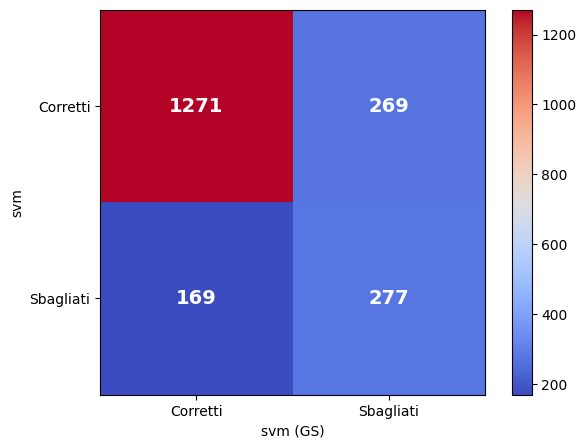

McNemar — X²=22.377, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): -0.0504
IC 95% differenza: [-0.0772, -0.0235]
→ svm è significativamente migliore di svm (GS)

svm vs xgboost


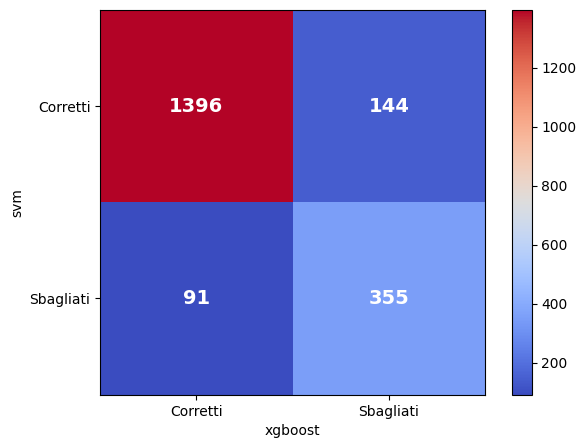

McNemar — X²=11.506, p-value=0.001
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): -0.0267
IC 95% differenza: [-0.0532, -0.0002]
→ svm è significativamente migliore di xgboost

svm vs xgboost (GS)


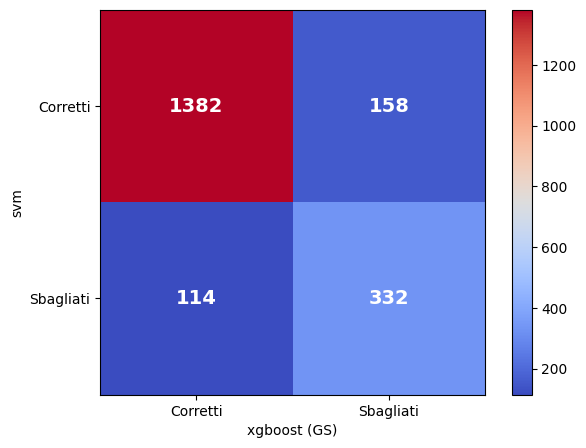

McNemar — X²=6.798, p-value=0.009
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): -0.0222
IC 95% differenza: [-0.0485, +0.0042]
→ Differenza non conclusiva (IC contiene 0)

svm vs lightgbm


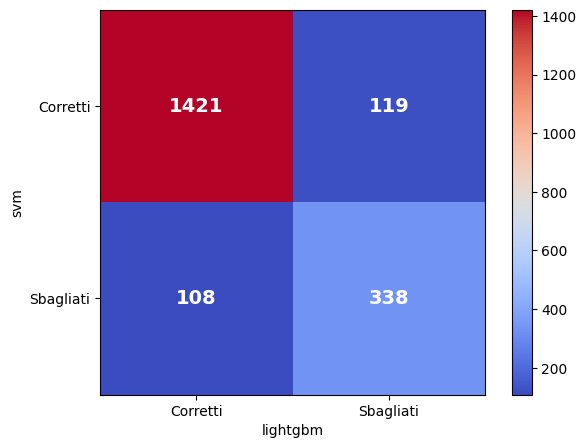

McNemar — X²=0.441, p-value=0.507
→ I modelli sono equivalenti (p > 0.05)
Diff errori (e1-e2): -0.0055
IC 95% differenza: [-0.0316, +0.0205]
→ Differenza non conclusiva (IC contiene 0)

svm vs lightgbm (GS)


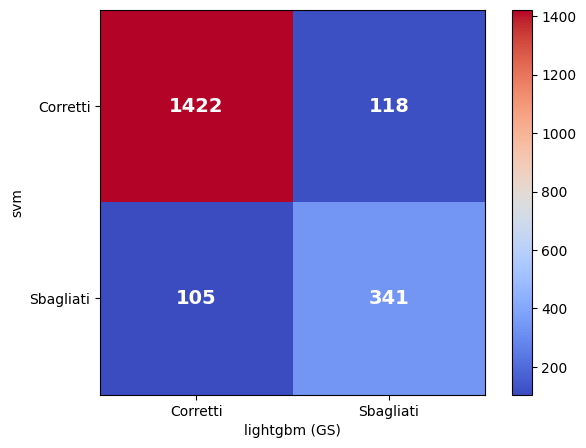

McNemar — X²=0.646, p-value=0.422
→ I modelli sono equivalenti (p > 0.05)
Diff errori (e1-e2): -0.0065
IC 95% differenza: [-0.0326, +0.0195]
→ Differenza non conclusiva (IC contiene 0)

svm (GS) vs xgboost


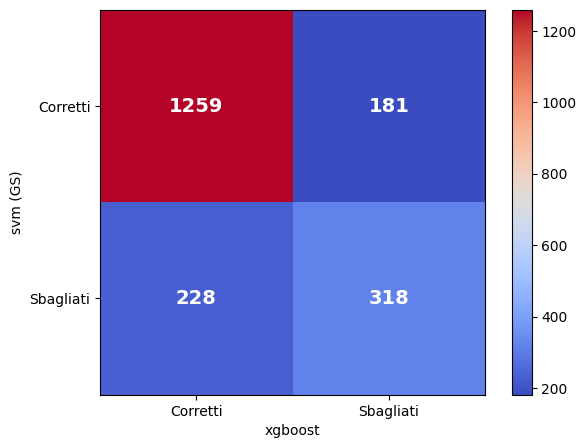

McNemar — X²=5.174, p-value=0.023
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0237
IC 95% differenza: [-0.0037, +0.0510]
→ Differenza non conclusiva (IC contiene 0)

svm (GS) vs xgboost (GS)


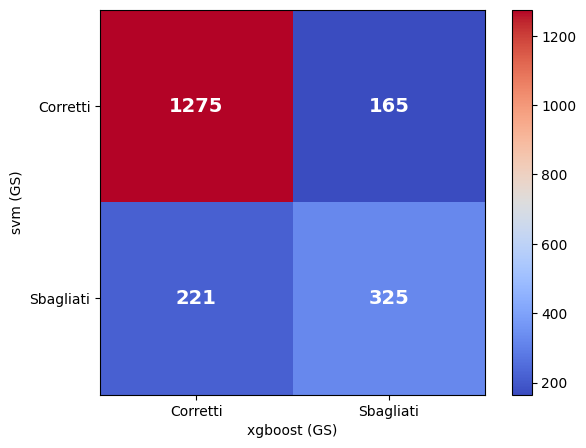

McNemar — X²=7.837, p-value=0.005
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0282
IC 95% differenza: [+0.0009, +0.0555]
→ xgboost (GS) è significativamente migliore di svm (GS)

svm (GS) vs lightgbm


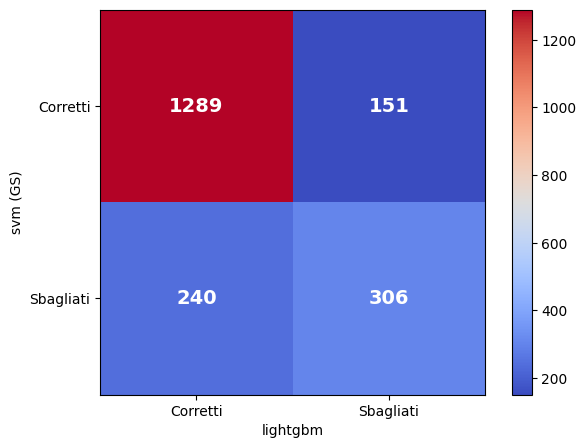

McNemar — X²=19.806, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0448
IC 95% differenza: [+0.0178, +0.0718]
→ lightgbm è significativamente migliore di svm (GS)

svm (GS) vs lightgbm (GS)


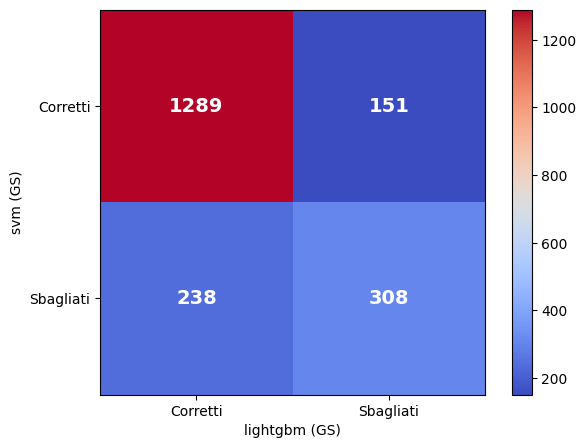

McNemar — X²=19.013, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0438
IC 95% differenza: [+0.0168, +0.0708]
→ lightgbm (GS) è significativamente migliore di svm (GS)

xgboost vs xgboost (GS)


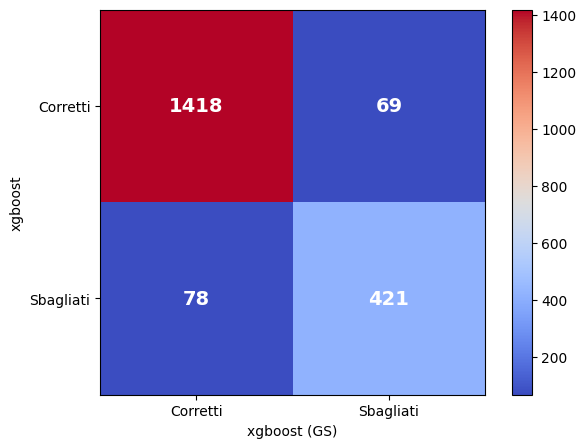

McNemar — X²=0.435, p-value=0.509
→ I modelli sono equivalenti (p > 0.05)
Diff errori (e1-e2): +0.0045
IC 95% differenza: [-0.0224, +0.0314]
→ Differenza non conclusiva (IC contiene 0)

xgboost vs lightgbm


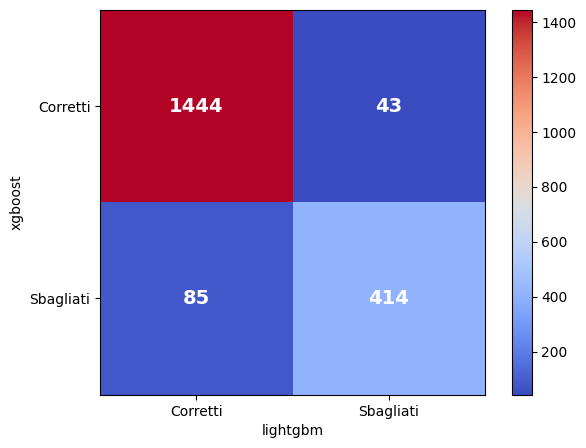

McNemar — X²=13.133, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0211
IC 95% differenza: [-0.0054, +0.0477]
→ Differenza non conclusiva (IC contiene 0)

xgboost vs lightgbm (GS)


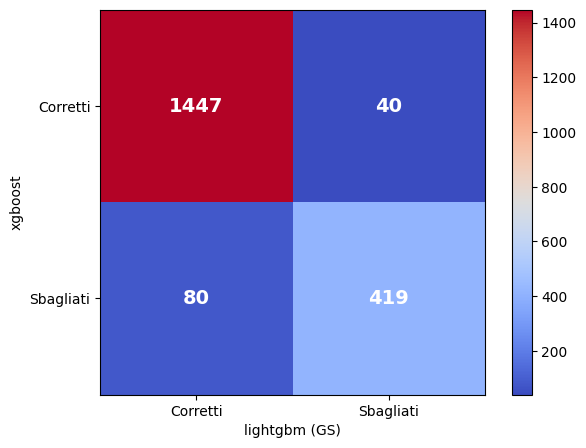

McNemar — X²=12.675, p-value=0.000
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0201
IC 95% differenza: [-0.0065, +0.0467]
→ Differenza non conclusiva (IC contiene 0)

xgboost (GS) vs lightgbm


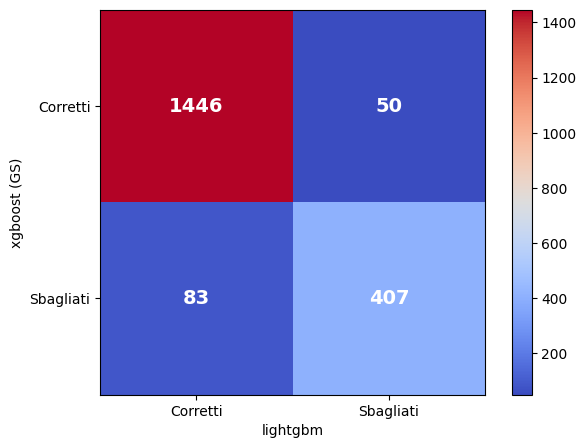

McNemar — X²=7.699, p-value=0.006
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0166
IC 95% differenza: [-0.0099, +0.0431]
→ Differenza non conclusiva (IC contiene 0)

xgboost (GS) vs lightgbm (GS)


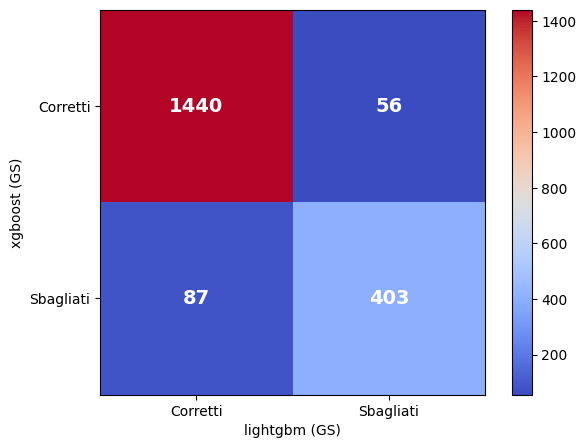

McNemar — X²=6.294, p-value=0.012
→ I modelli sono significativamente diversi (p ≤ 0.05)
Diff errori (e1-e2): +0.0156
IC 95% differenza: [-0.0109, +0.0421]
→ Differenza non conclusiva (IC contiene 0)

lightgbm vs lightgbm (GS)


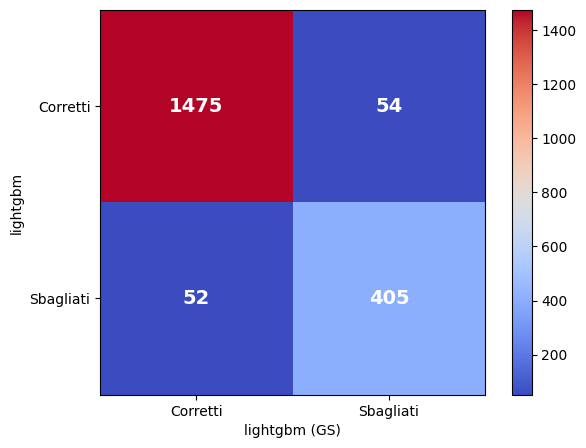

McNemar — X²=0.009, p-value=0.923
→ I modelli sono equivalenti (p > 0.05)
Diff errori (e1-e2): -0.0010
IC 95% differenza: [-0.0272, +0.0252]
→ Differenza non conclusiva (IC contiene 0)



In [ ]:
confronta_modelli(predizioni_finali)

#### Gerarchia delle Performance

Dal confronto statistico tramite test di McNemar emergono tre gruppi distinti di modelli:

**Gruppo superiore** — Regressione Logistica (default e GS), SVM (default) e LightGBM (default e GS) si posizionano in cima con accuracy tra il 76% e il 79%. Il test di McNemar conferma che questi tre modelli non sono statisticamente distinguibili tra loro (p > 0.05 in tutti i confronti interni al gruppo), il che significa che le differenze osservate nelle accuracy potrebbero essere dovute al caso.

**Gruppo intermedio** — XGBoost (default e GS) e SVM (GS) si collocano intorno al 72-76%. Sono significativamente migliori dei modelli deboli ma statisticamente inferiori al gruppo superiore.

**Gruppo inferiore** — Perceptron (default e GS), Decision Tree (Default e GS), ottengono le performance peggiori. Il Perceptron è significativamente inferiore a tutti gli altri modelli senza eccezioni.

#### Osservazioni Notevoli

**La GridSearch non sempre migliora i risultati sul test set.**
Questo perché ottimizza gli iperparametri minimizzando l'errore in cross-validation sul training set, non sul test set fisso.

I casi più evidenti sono:
- **SVM**: il modello default (77.54%) è significativamente migliore di quello ottimizzato (72.51%).
- **LR e LightGBM**: la GridSearch produce modelli praticamente equivalenti al default (p > 0.05), il che suggerisce che i parametri di default siano già prossimi all'ottimo per questo dataset.

**McNemar e IC della differenza non sempre concordano.**
In alcuni casi (es. `svm vs xgboost (GS)`, `xgboost vs lightgbm`) il test di McNemar da una differenza significativa ma l'IC della differenza degli errori contiene 0. Questo accade perché McNemar considera quali istanze vengono classificate diversamente mentre l'IC si basa unicamente sulla differenza fra le accuracy.

**Modelli lineari competitivi con modelli complessi.**
La Regressione Logistica (78.20%) è statisticamente equivalente a SVM e LightGBM nonostante sia un modello molto più semplice. Questo suggerisce che le relazioni tra le feature e il burnout nel dataset siano in larga parte lineari, e che la complessità aggiuntiva dei modelli più complessi non si traduca in un vantaggio misurabile su questi dati.


### Conclusione sul Modello Migliore

Il modello raccomandato è la **Regressione Logistica** per le seguenti ragioni:
- Accuracy tra le più alte (78.20% e 78.05%), statisticamente equivalente ai modelli più complessi
- Completamente interpretabile tramite i coefficienti, che permettono di capire quali variabili influenzano maggiormente il burnout
- Tempi di training e inferenza trascurabili rispetto a SVM e LightGBM
- La GridSearch non porta miglioramenti significativi, il che indica che i parametri di default si avvicinano già all'ottimalità.

Per queste ragioni nell'applicativo Web è stato implementato il modello di default della Regressione Logistica

### Applicativo Web

Di seguito sono presenti le celle per eseguire l'applicativo web

In [ ]:
import os
!pip install flask scikit-learn pandas pyngrok -q
import subprocess, time, requests
from pyngrok import ngrok, conf

In [ ]:
REPO_URL = "https://github.com/Martina-Ravaioli/Progetto_DataIntensive.git"
!git clone {REPO_URL}

repo_dir = REPO_URL.split('/')[-1].replace('.git', '')
os.chdir(f"{repo_dir}/Progetto")

Cloning into 'Progetto_DataIntensive'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 75 (delta 35), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 3.85 MiB | 7.89 MiB/s, done.
Resolving deltas: 100% (35/35), done.


In [ ]:
flask_proc = subprocess.Popen(
    ["python", "predict.py"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

for i in range(15):
    try:
        r = requests.get("http://localhost:5001", timeout=2)
        print(f"Flask attivo")
        break
    except:
        time.sleep(1)
else:
    print(flask_proc.stderr.read().decode())

Flask attivo


In [26]:
NGROK_TOKEN = "3EfDtaL11Njy7uuGkWFiqu9Kk6V_3zB8qQntHtCAojyfKLkpV"
conf.get_default().auth_token = NGROK_TOKEN
public_url = ngrok.connect(5001)

print(f"Link Pubblico: {public_url}")

Link Pubblico: NgrokTunnel: "https://daily-output-lanky.ngrok-free.dev" -> "http://localhost:5001"


Si consiglia di aprire il link pubblico nella finestra di navigazione in incognito per evitare che alcune estensioni browser possano manomettere l'HTML del sito.

Una volta terminato l'utilizzo del sito è imporante eseguire la cella successiva che elimina la connessione a grok in quanto una sola è mantenibile accesa nello stesso momento.

In [27]:
ngrok.kill()